## Data Preparation


### Load Packages

In [1]:
import pickle
import pandas as pd
import numpy as np
import re
from collections import Counter
from scipy.stats import pearsonr

import seaborn as sns
import matplotlib.pyplot as plt
#plt.style.use('ggplot')

import json
import csv
import os

### Load Data

In [60]:
df_data = pd.read_csv('./data/WVS_Time_Series_1981-2022_csv_v5_0_original.csv') # took 23 seconds on mine

In [2]:
variable_equivalence_df = pd.read_excel('./data/WVS_Time_Series_List_of_Variables_and_equivalences_1981_2022_v3_1.xlsx')

#### Response Data

In [149]:
df_data.shape

(443488, 1046)

In [115]:
df_data.head(5)

,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,S004,S006,...,Y023A,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg
0,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,3,8,ALB,339,ALB,1,1,...,0.000000,0.444444,0.444444,0.33,0.0,0.165,-1.011276,0.160847,0.158964,-1.792410
1,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,3,8,ALB,339,ALB,1,2,...,0.111111,0.444444,0.444444,0.33,0.0,0.165,-0.688773,0.409283,0.558946,-1.208679
2,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,3,8,ALB,339,ALB,1,3,...,0.000000,0.444444,0.444444,0.33,0.5,0.415,NaN,NaN,NaN,NaN
3,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,3,8,ALB,339,ALB,1,4,...,0.000000,0.333333,0.333333,0.33,0.0,0.165,-1.319863,0.733956,1.081669,-2.350952
4,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,3,8,ALB,339,ALB,1,5,...,0.000000,0.333333,0.333333,0.00,0.5,0.250,NaN,NaN,NaN,NaN


#### Variable Equivalence

In [3]:
variable_equivalence_df.head(20)

,Unnamed: 0,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
0,NaN,A001,Important in life: Family,Q1,V4,V4,V4,V4,V5,NaN
1,NaN,A002,Important in life: Friends,Q2,V5,V5,V5,V5,V6,NaN
2,NaN,A003,Important in life: Leisure time,Q3,V6,V6,V6,V6,V7,NaN
3,NaN,A004,Important in life: Politics,Q4,V7,V7,V7,V7,V8,NaN
4,NaN,A005,Important in life: Work,Q5,V8,V8,V8,V8,V4,NaN
5,NaN,A006,Important in life: Religion,Q6,V9,V9,V9,V9,V9,NaN
6,NaN,A007,Important in life: Service to others,NaN,NaN,NaN,V10,NaN,NaN,NaN
7,NaN,A008,Feeling of happiness,Q46,V10,V10,V11,V10,V18,V10
8,NaN,A009,State of health (subjective),Q47,V11,V11,V12,V11,V83,V11
9,NaN,A010,Ever felt very excited or interested,NaN,NaN,NaN,NaN,NaN,V84,NaN


In [4]:
del variable_equivalence_df['Unnamed: 0']

The `variable_equivalence_df` contains information about question codes corresponding to value items from each wave. We can use this data to identify value items that are asked in more than any specified number of waves. This may be useful if we are limiting our study on value items that appear in, for example, 5 or more waves so we have more complete data. 

#### Item codes

In [137]:
df_data = pd.read_csv('./data/WVS_Wave_7.csv') 

In [140]:
item_177 = pd.read_csv('./data/177_items.csv') 

In [138]:
variables = list(df_data.columns[1:])

In [139]:
variables

['A001',
 'A002',
 'A003',
 'A004',
 'A005',
 'A006',
 'A008',
 'A009',
 'A062',
 'A165',
 'A170',
 'A173',
 'B008',
 'C001',
 'C001_01',
 'C002',
 'C002_01',
 'C006',
 'C038',
 'C039',
 'C041',
 'D001_B',
 'D026_03',
 'D026_05',
 'D054',
 'D057',
 'D059',
 'D060',
 'D061',
 'D066_B',
 'D066_01',
 'D078',
 'E001',
 'E003',
 'E004',
 'E005',
 'E006',
 'E015',
 'E016',
 'E018',
 'E023',
 'E025',
 'E026',
 'E027',
 'E028',
 'E034',
 'E035',
 'E036',
 'E037',
 'E039',
 'E040',
 'E069_01',
 'E069_04',
 'E069_05',
 'E069_07',
 'E069_08',
 'E069_10',
 'E069_12',
 'E069_13',
 'E069_14',
 'E069_15',
 'E069_40',
 'E069_41',
 'E069_54',
 'E114',
 'E115',
 'E117',
 'E117B',
 'E124',
 'E224',
 'E225',
 'E226',
 'E227',
 'E229',
 'E233',
 'E233A',
 'E233B',
 'E235',
 'E236',
 'E248B',
 'E254B',
 'E258B',
 'E259B',
 'E260B',
 'E261B',
 'E262B',
 'E268',
 'E277',
 'E289',
 'E286',
 'E287',
 'F028',
 'F028B',
 'F034',
 'F114A',
 'F114B',
 'F114C',
 'F114D',
 'F116',
 'F117',
 'F120',
 'F121',
 'F122',


In [ ]:
# CAT_COL = ['A165', 'B008', 'C001','C002',
#            'E001', 'E002', 'E003', 'E004', 'E005', 
#            'E006', 'E034',  'E277', 'F025', 
#            'G027A', 'H008_07', 'H008_08']

In [ ]:
# item_127 = item_177[item_177['code'].isin(variables)]

In [ ]:
# filtered_df = (
# variable_equivalence_df[variable_equivalence_df['Variable'].isin(variables)]
#     .loc[:, ['WVS7', 'Title', 'Variable']]
#     .rename(columns={
#         'WVS7': 'survey_q',
#         'Title': 'q_content',
#         'Variable': 'code'
#     })
# )

In [ ]:
# filtered_df.reset_index(inplace=True)

In [ ]:
# filtered_df.drop(columns = ['index'], inplace=True)

In [44]:
# filtered_df

,survey_q,q_content,code,set,s_category,q_content_extracted
0,Q1,Important in life: Family,A001,,Important in life,Family
1,Q2,Important in life: Friends,A002,,Important in life,Friends
2,Q3,Important in life: Leisure time,A003,,Important in life,Leisure time
3,Q4,Important in life: Politics,A004,,Important in life,Politics
4,Q5,Important in life: Work,A005,,Important in life,Work
...,...,...,...,...,...,...
172,Q53,Frequency you/family (last 12 month): Gone wit...,H008_03,,Frequency you/family (last 12 month),Gone without needed medicine or treatment that...
173,Q54,Frequency you/family (last 12 month): Gone wit...,H008_04,,Frequency you/family (last 12 month),Gone without a cash income
174,Q149,Freedom and Equality - Which more important,H008_07,,Freedom and Equality,Which more important
175,Q150,Freedom and securiy - Which more important,H008_08,,Freedom and securiy,Which more important


In [ ]:
# # Add set column (blank by default)
# filtered_df['set'] = ''

In [ ]:
# pattern = r'^\s*(.*?)\s*(?:\:|\-)\s*(.*?)\s*$'

# filtered_df[['s_category', 'q_content_extracted']] = (
#     filtered_df['q_content']
#     .str.extract(pattern)
# )

In [ ]:
# # If regex matched, replace q_content with extracted B
# filtered_df['q_content'] = filtered_df['q_content_extracted'].fillna(filtered_df['q_content'])

# # If no match, s_category should be blank
# filtered_df['s_category'] = filtered_df['s_category'].fillna('')


# # Drop helper column
# filtered_df = filtered_df.drop(columns=['q_content_extracted'])

In [46]:
# filtered_df

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,,Important in life
1,Q2,Friends,A002,,Important in life
2,Q3,Leisure time,A003,,Important in life
3,Q4,Politics,A004,,Important in life
4,Q5,Work,A005,,Important in life
...,...,...,...,...,...
172,Q53,Gone without needed medicine or treatment that...,H008_03,,Frequency you/family (last 12 month)
173,Q54,Gone without a cash income,H008_04,,Frequency you/family (last 12 month)
174,Q149,Which more important,H008_07,,Freedom and Equality
175,Q150,Which more important,H008_08,,Freedom and securiy


In [ ]:
# item_127.to_csv(f'./data/127_items.csv', index=False)

### Demographic Information

In [5]:
demo_ve_df = variable_equivalence_df.iloc[962:1011] # 962 to 1010
demo_ve_df

,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
962,X001,Sex,Q260,V240,V235,V223,V214,V353,V214
963,X002,Year of birth,Q261,V241,V236,V224,V215,V354,V215
964,X002_02A,Respondents country of birth - ISO 3166-1 code,Q266,NaN,NaN,NaN,NaN,NaN,NaN
965,X003,Age,Q262,V242,V237,V225,V216,V355,V216
966,X003R,Age recoded (6 intervals),X003R,X003R,V237R,V225R,v216R,X003R,X003R
967,X003R2,Age recoded (3 intervals),X003R2,X003R2,V237R2,V225R2,v216R2,X003R2,X003R2
968,X007,Marital status,Q273,V57,V55,V106,V89,V181,V89
969,X008,Have you been married before,NaN,NaN,NaN,NaN,NaN,V182,NaN
970,X010,Where r lived after married,NaN,NaN,NaN,IV67,NaN,NaN,NaN
971,X011,How many children do you have,Q274,V58,V56,V107,V90,V211,V90


In [6]:
demo_ve_df.Variable

962          X001
963          X002
964      X002_02A
965          X003
966         X003R
967        X003R2
968          X007
969          X008
970          X010
971          X011
972         X011A
973          X012
974          X013
975          X023
976         X023R
977         X024B
978          X025
979      X025A_01
980     X025CSWVS
981       X025LIT
982         X025R
983          X026
984          X028
985          X031
986          X036
987         X036E
988          X040
989          X041
990          X043
991          X044
992          X045
993         X045B
994          X046
995      X047_WVS
996        X047CS
997     X047R_WVS
998       X048ISO
999       X048WVS
1000         X049
1001        X049A
1002       X049CS
1003         X050
1004        X050B
1005        X050C
1006         X051
1007         X052
1008         X053
1009         X054
1010         X055
Name: Variable, dtype: object

### Data Transformation and Representation

#### Generate Wave-Specific Data

##### Demographic Items

In [21]:
wave_7_demo_index = list(set(demo_ve_df.Variable).intersection(df_data.columns))

In [22]:
wave_7_demo = df_data[df_data['S002VS'] == 7][wave_7_demo_index]

In [23]:
wave_7_demo

,X023,X025A_01,X025,X031,X002_02A,X050,X002,X043,X047R_WVS,X054,...,X050B,X007,X026,X048ISO,X055,X036E,X001,X040,X036,X049CS
3002,-4,3,-4,-4,724,-4,1958,-4,2,-4,...,1,1,0,20007,-4,4,2,0,-4,-4
3003,-4,7,-4,-4,20,-4,1971,-4,3,-4,...,2,2,0,20003,-4,1,1,1,-4,-4
3004,-4,7,-4,-4,724,-4,1969,-4,2,-4,...,2,4,0,20003,-4,5,1,1,-4,-4
3005,-4,2,-4,-4,724,-4,1956,-4,2,-4,...,2,2,0,20003,-4,4,2,0,-4,-4
3006,-4,2,-4,-4,724,-4,1969,-4,2,-4,...,2,2,0,20003,-4,4,1,1,-4,-4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443483,-4,1,-4,-4,716,-4,1977,-4,2,-4,...,5,1,0,716010,-4,0,2,0,-4,-4
443484,-4,6,-4,-4,716,-4,1986,-4,2,-4,...,5,1,0,716010,-4,1,1,1,-4,-4
443485,-4,2,-4,-4,716,-4,1998,-4,2,-4,...,5,1,1,716010,-4,0,2,0,-4,-4
443486,-4,2,-4,-4,716,-4,1972,-4,1,-4,...,5,1,0,716010,-4,9,2,1,-4,-4


In [24]:
wave_7_demo.to_csv(f'./data/WVS_Wave_7_demo.csv', index=False)

##### Dealing with Missing Values - Filtering Out Questions Not Asked to All Countries

If we simply filter by wave, the resulting dataframe includes many columns where the corresponding question is not asked in that wave at all or questions that are only asked in a handful of countries. We want to prepare cleaner data to work on. One approach is to filter out questions that are not asked to all countries in that specific wave. This is because the WVS allows the regional survey asministrators a great degree of freedom in terms of the questions they choose to ask. For example, the survey in an Southeast Asian country will probably include question about the interviewee's confidence in ASEAN and the survey administered in a European country is not likely to include this question.

In [61]:
wave_7 = df_data[df_data['S002VS'] == 7]

In [62]:
wave_7.shape

(97220, 1046)

In [123]:
wave_7_sci_tech = wave_7[['COUNTRY_ALPHA', 'E217', 'E218', 'E220', 'I001', 'I002', 'E234']]
wave_7_sci_tech.to_csv(f'./data/WVS_Wave_7_sci_tech.csv', index=False)

#### Filter by Question Type

In [75]:
capital_start_regex = re.compile(r"^[A-I]\d+") 
# This regex expression finds all survey items that are not demographic, composite, or administrative
# It matches all items formatted as one capitalized letter between A to I followed by indefinite number of numbers

In [76]:
# Country-Specific Questions Found Manually
manual_items = ['E179WVS', 'E179_WVS7LOC', 'E180WVS', 'E182', 'F025_WVS', 'G015', 'G015B', 'G016', 'G026_01', 'G027_01'] 
# this list combined with any questions ending in 'CS' are all Country-Specific questions

In [77]:
items

Index(['version', 'doi', 'S001', 'S002VS', 'S003', 'COUNTRY_ALPHA', 'COW_NUM',
       'COW_ALPHA', 'S004', 'S006',
       ...
       'Y023A', 'Y023B', 'Y023C', 'Y024A', 'Y024B', 'Y024C', 'survself',
       'tradrat5', 'TradAgg', 'SurvSAgg'],
      dtype='object', length=1046)

In [78]:
# Filtering Out demographic, composite, administrative, and country-specific items 
value_items = [value_item for value_item in wave_7.columns \
               if capital_start_regex.match(value_item) \
               and not value_item.endswith('CS') \
               and value_item not in manual_items]
value_items[:5]

['A001', 'A002', 'A003', 'A004', 'A005']

In [79]:
len(value_items)

904

We have 904 items that belong to section A to I and are not Country-Specific querstions. However, among these 904 items, not all are administered in Wave 7. And among those administered in Wave 7, not all are asked in all countries. 

#### Filter by Missing Responses

After filtering out the country-specific and the demographic questions, we are left with 904 value items. Then, we want to filter out value items are are not asked in all countries for each wave. 

In [80]:
# For Argentina at Wave 7, whether any answer to A080_02 is not missing
any(wave_7[wave_7['COUNTRY_ALPHA'] == 'ARG']['A080_02'] >= 0)

True

In [88]:
sum(wave_7[wave_7['COUNTRY_ALPHA'] == 'ARG']['A070'] >= 0)

0

In [89]:
len(wave_7[wave_7['COUNTRY_ALPHA'] == 'ARG']['A070'])

1003

We should find items that are asked in all countries included in Wave 7. If the item has any non-negative response in one country, it is asked in this country. So, if the item has any non-negative responses for all 66 countries included in Wave 7, we include the item in our analysis. 

In [81]:
value_items_w7 = []
for v_i in value_items:
    all_ctry_asked = True
    for c in countries:
        if not any(wave_7[wave_7['COUNTRY_ALPHA'] == c][v_i] >= 0):
            all_ctry_asked = False
    if all_ctry_asked:
        value_items_w7.append(v_i)

**Update**: We decide to  use items that have a valid response rate of >= 50% for each country. 

In [63]:
countries = wave_7.COUNTRY_ALPHA.unique()
countries

array(['AND', 'ARG', 'ARM', 'AUS', 'BGD', 'BOL', 'BRA', 'CAN', 'CHL',
       'CHN', 'COL', 'CYP', 'CZE', 'DEU', 'ECU', 'EGY', 'ETH', 'GBR',
       'GRC', 'GTM', 'HKG', 'IDN', 'IND', 'IRN', 'IRQ', 'JOR', 'JPN',
       'KAZ', 'KEN', 'KGZ', 'KOR', 'LBN', 'LBY', 'MAC', 'MAR', 'MDV',
       'MEX', 'MMR', 'MNG', 'MYS', 'NGA', 'NIC', 'NIR', 'NLD', 'NZL',
       'PAK', 'PER', 'PHL', 'PRI', 'ROU', 'RUS', 'SGP', 'SRB', 'SVK',
       'THA', 'TJK', 'TUN', 'TUR', 'TWN', 'UKR', 'URY', 'USA', 'UZB',
       'VEN', 'VNM', 'ZWE'], dtype=object)

In [65]:
items = wave_7.columns

In [70]:
wave_7

,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,S004,S006,...,Y023A,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg
3002,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070001,...,0.333333,0.111111,0.444444,0.00,0.0,0.000,NaN,NaN,NaN,NaN
3003,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070002,...,0.888889,0.888889,0.888889,1.00,0.0,0.500,2.351776,-0.409820,-0.759811,4.294714
3004,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070003,...,1.000000,0.444444,0.555556,0.33,0.5,0.415,0.745465,1.080443,1.639513,1.387292
3005,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070004,...,0.555556,0.333333,0.888889,0.33,0.5,0.415,NaN,NaN,NaN,NaN
3006,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,20,AND,232,AND,-4,20070005,...,0.777778,0.444444,0.666667,0.00,0.5,0.250,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
443483,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,716,ZWE,552,ZIM,-4,716071211,...,0.000000,0.000000,0.000000,0.66,0.5,0.580,-0.738923,-0.774148,-1.346378,-1.299450
443484,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,716,ZWE,552,ZIM,-4,716071212,...,0.000000,0.000000,0.777778,1.00,0.0,0.500,-0.445039,0.282275,0.354463,-0.767520
443485,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,716,ZWE,552,ZIM,-4,716071213,...,0.000000,0.000000,0.000000,0.33,0.0,0.165,-0.925464,-0.436454,-0.802691,-1.637090
443486,5-0-0 (2024-04-30),doi.org/10.14281/18241.25,2,7,716,ZWE,552,ZIM,-4,716071214,...,0.000000,0.000000,0.000000,0.00,0.0,0.000,-2.398929,1.218936,1.862486,-4.304062


In [71]:
invalid_ints = {-1, -2, -3, -4, -5}

col_num = pd.to_numeric(wave_7["doi"], errors="coerce")

invalid_mask = (
    col_num.isin(invalid_ints) &   # catches -1, "-1", -1.0
    (col_num % 1 == 0)             # ensures it's an integer
)

df_valid = wave_7[~invalid_mask]


In [74]:
invalid_ints = {-1, -2, -3, -4, -5}

def is_valid(series):
    num = pd.to_numeric(series, errors="coerce")
    invalid = num.isin(invalid_ints) & (num % 1 == 0)
    return ~invalid


In [75]:
value_items_w7 = []
valid_response_rate_df = pd.DataFrame(index=countries, columns=items)

for v_i in items:
    record = True

    for c in countries:
        sub = wave_7.loc[wave_7["COUNTRY_ALPHA"] == c, v_i]

        valid_mask = is_valid(sub)

        valid_response_rate = valid_mask.sum() / len(sub)
        valid_response_rate_df.loc[c, v_i] = valid_response_rate

        if valid_response_rate < 0.5:
            record = False
            break

    if record:
        value_items_w7.append(v_i)


In [92]:
valid_response_rate_df

,A001,A002,A003,A004,A005,A006,A008,A009,A010,A011,...,H008_05,H008_06,H008_07,H008_08,H008_09,H009,H010,H011,I001,I002
AND,1.0,1.0,1.0,0.998008,0.998008,0.998008,1.0,1.0,0.0,0.0,...,0.999004,0.996016,0.997012,0.996016,0.99502,0.999004,1.0,0.999004,0.99502,1.0
ARG,1.0,1.0,0.996012,0.998006,0.994018,0.987039,0.98006,0.998006,NaN,NaN,...,0.974078,0.876371,0.996012,0.995015,0.992024,0.949153,0.956132,0.948156,0.922233,0.98006
ARM,1.0,0.999182,0.987735,0.994276,0.997547,0.996729,0.991823,0.999182,NaN,NaN,...,0.954211,0.914146,0.966476,0.982829,0.999182,0.9722,0.943581,0.968111,0.91251,0.991823
AUS,0.994484,0.974076,0.96856,0.960287,0.957529,0.970767,0.995587,0.990623,NaN,NaN,...,0.982901,0.975179,0.986762,0.969664,0.991175,0.992278,0.988969,0.991175,0.987314,0.990623
BGD,1.0,0.996667,0.990833,0.971667,0.995833,0.9975,1.0,1.0,NaN,NaN,...,0.985833,0.943333,0.994167,0.995,0.978333,0.936667,0.848333,0.885,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,0.998844,0.994992,0.994607,0.991525,0.993066,0.993837,0.996918,0.996533,NaN,NaN,...,NaN,NaN,0.990755,0.98228,0.996148,NaN,NaN,NaN,0.987673,0.988444
UZB,1.0,0.9976,0.9952,0.9872,0.9976,0.9816,0.9832,0.9968,NaN,NaN,...,NaN,NaN,0.9496,0.9472,0.94,NaN,NaN,NaN,0.9504,0.9536
VEN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,0.0,0.0
VNM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,NaN,...,NaN,NaN,1.0,1.0,1.0,NaN,NaN,NaN,NaN,NaN


In [76]:
valid_response_rate_df.to_csv('./data/wvs_w7_valid_response_rate.csv')

In [ ]:
value_items_w7

In [ ]:
len(value_items_w7)

In [79]:
wave_7 = wave_7[['COUNTRY_ALPHA'] + value_items_w7]

In [97]:
wave_7.to_csv(f'./data/WVS_Wave_7.csv', index=False)

### Check overlap between original 40 items

In [7]:
new_127 = pd.read_csv("./data/127_items.csv")
new_162 = pd.read_csv("./data/162_items.csv")
old_40 = pd.read_csv("./data/40items_info.csv")
old_75 = pd.read_csv("./data/75items_info.csv")

In [56]:
overlap = old_40[old_40['survey_q'].isin(new_127['survey_q'])]
print(len(overlap))

20


In [32]:
overlap

,survey_q,q_content,code,set,s_category
10,Q64,The churches,E069_01,C2,Confidence
12,Q66,The press,E069_04,C2,Confidence
13,Q68,Labor unions,E069_05,C2,Confidence
15,Q73,Parliament,E069_07,C2,Confidence
16,Q74,The civil service,E069_08,C2,Confidence
17,Q77,Major companies,E069_13,C2,Confidence
18,Q43,Less importance placed on work in our lives,E015,C3,Future changes
19,Q44,More emphasis on the development of technology,E016,C3,Future changes
20,Q45,Greater respect for authority,E018,C3,Future changes
21,Q177,Claiming government benefits to which you are ...,F114A,C4,Justifiable


In [57]:
new_177 = pd.read_csv("./data/177_items.csv")

In [58]:
new_177

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,C10,Important in life
1,Q2,Friends,A002,C10,Important in life
2,Q3,Leisure time,A003,C10,Important in life
3,Q4,Politics,A004,C10,Important in life
4,Q5,Work,A005,C10,Important in life
...,...,...,...,...,...
172,Q254,How proud of nationality,G006,C9,Proud of nationality
173,Q258,Continent; e.g. Europe Asia etc.,G062,C46,How close you feel
174,Q259,World,G063,C46,How close you feel
175,Q263,Respondent immigrant,G027A,C43,Immigrant


In [66]:
overlap = old_75[old_75['survey_q'].isin(new_162['survey_q'])]
print(len(overlap))

53


In [67]:
overlap

,survey_q,q_content,code,set,s_category
11,Q64,The churches,E069_01,C2,Confidence
12,Q65,The armed forces,E069_02,C2,Confidence
13,Q66,The press,E069_04,C2,Confidence
14,Q67,Television,E069_10,C2,Confidence
15,Q68,Labor unions,E069_05,C2,Confidence
16,Q69,The police,E069_06,C2,Confidence
17,Q70,The courts,E069_17,C2,Confidence
18,Q71,The government,E069_11,C2,Confidence
19,Q72,Political parties,E069_12,C2,Confidence
20,Q73,Parliament,E069_07,C2,Confidence


### Visualize valid response rate. 

In [151]:
valid_response_rate_df = pd.read_csv("./data/wvs_w7_valid_response_rate.csv")

In [152]:
valid_response_rate_df = valid_response_rate_df.set_index('Unnamed: 0')

In [153]:
valid_response_rate_df

,version,doi,S001,S002VS,S003,COUNTRY_ALPHA,COW_NUM,COW_ALPHA,S004,S006,...,Y023A,Y023B,Y023C,Y024A,Y024B,Y024C,survself,tradrat5,TradAgg,SurvSAgg
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AND,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARG,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AUS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BGD,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
UZB,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
VEN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [154]:
valid_response_rate_df.shape

(66, 1046)

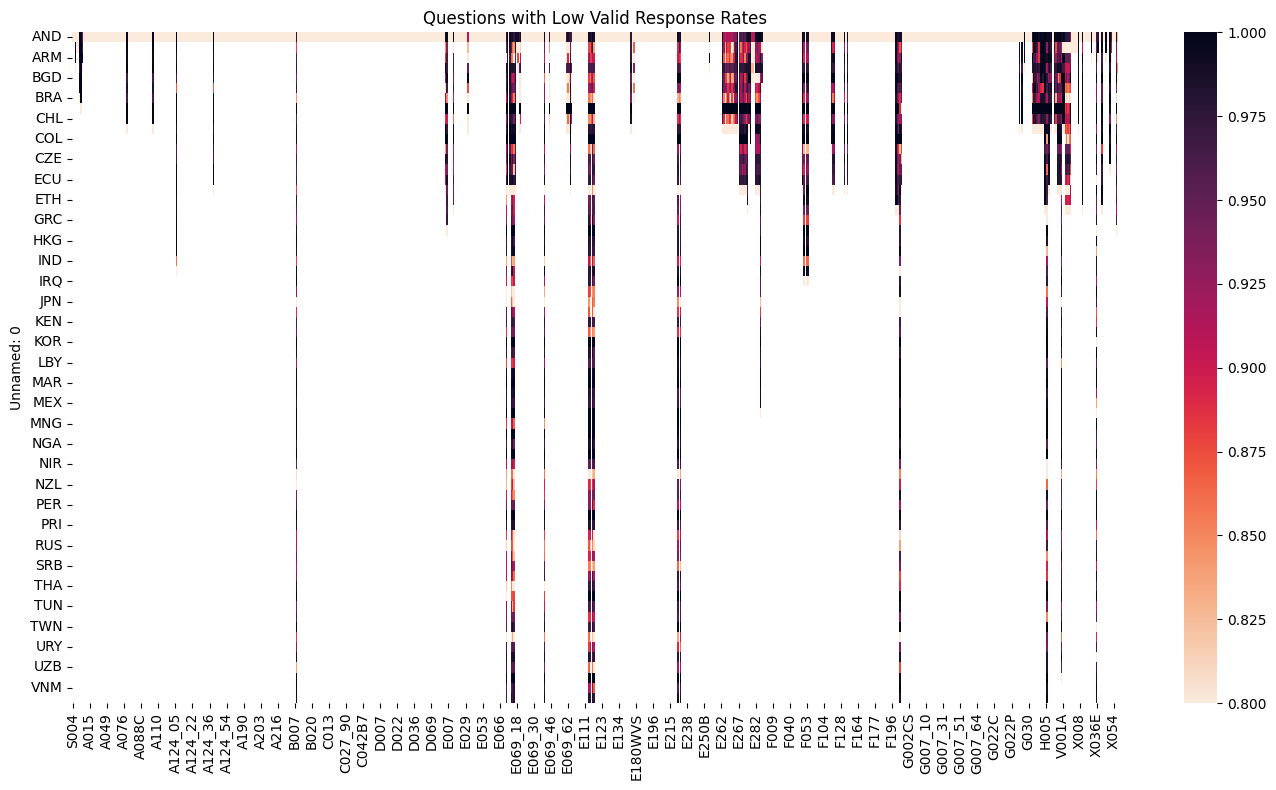

In [84]:
low_q = valid_response_rate_df.columns[valid_response_rate_df.mean() < 0.95]

plt.figure(figsize=(14, 8))
sns.heatmap(
    valid_response_rate_df[low_q],
    cmap='rocket_r',
    vmin=0.8, vmax=1.0
)
plt.title("Questions with Low Valid Response Rates")
plt.tight_layout()
plt.show()


In [85]:
# mean across questions → one value per question
q_mean = valid_response_rate_df.mean(axis=0)


In [86]:
q_mean

version     1.0
doi         1.0
S001        1.0
S002VS      1.0
S003        1.0
           ... 
Y024C       1.0
survself    1.0
tradrat5    1.0
TradAgg     1.0
SurvSAgg    1.0
Length: 1046, dtype: float64

In [87]:
q_mean_sorted = q_mean.sort_values(ascending=True)


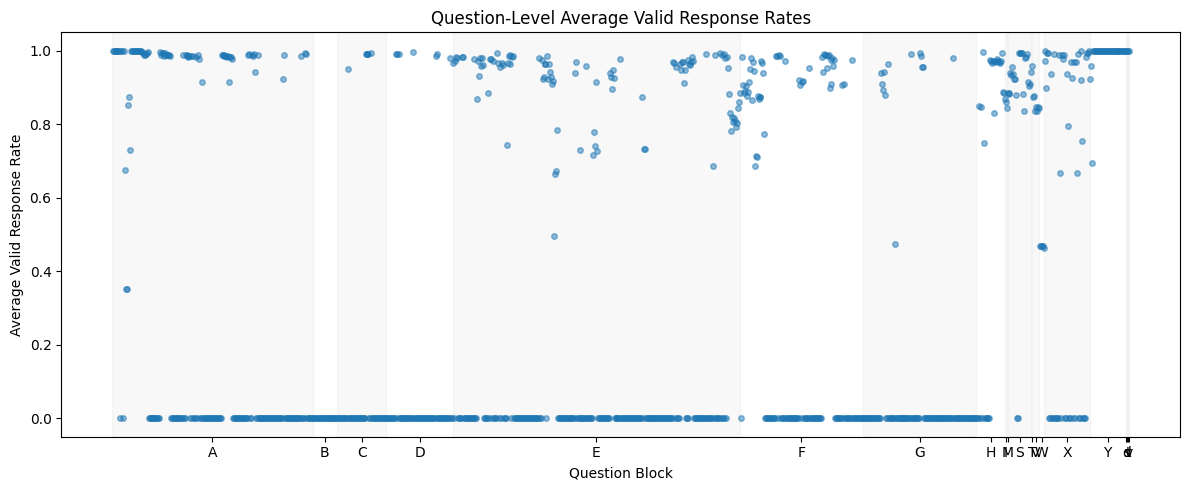

In [88]:
import matplotlib.pyplot as plt
import pandas as pd

# Ensure index is a Series we can work with
q_mean = q_mean.copy()

# Extract first letter (A–I)
groups = q_mean.index.to_series().str[0]

# Numeric x positions
x = range(len(q_mean))

plt.figure(figsize=(12, 5))
plt.plot(x, q_mean.values, marker='o', markersize = 4, linestyle='', alpha=0.5)

ax = plt.gca()

# --- Create blocks + centered tick labels ---
xticks = []
xtick_labels = []

start = 0


for i, (letter, idxs) in enumerate(groups.groupby(groups).groups.items()):
    end = start + len(idxs)

    if i % 2 == 0:
        ax.axvspan(
            start - 0.5, end - 0.5,
            color='gray',
            alpha=0.05,
            zorder=0
        )

    # Center tick for this block
    center = (start + end - 1) / 2
    xticks.append(center)
    xtick_labels.append(letter)

    start = end

ax.set_xticks(xticks)
ax.set_xticklabels(xtick_labels)

plt.xlabel("Question Block")
plt.ylabel("Average Valid Response Rate")
plt.title("Question-Level Average Valid Response Rates")
plt.tight_layout()
plt.savefig("./question_level_valid_response_rate.png", dpi = 300)
plt.show()


In [155]:
# create mapping dict
col_map = dict(zip(variable_equivalence_df["Variable"], variable_equivalence_df["WVS7"]))
len(col_map)

1048

In [ ]:
# revise
col_map['E111'] = 'Q252'
del col_map['E111_01']

In [160]:
# replace column names
valid_response_rate_df = valid_response_rate_df.rename(columns=col_map)
valid_response_rate_df


,version,doi,S001,A_WAVE,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,S004,S006,...,I_HOMOLIB,I_ABORTLIB,I_DIVORLIB,I_VOICE1,I_VOICE2,I_VOI2_00,survself,tradrat5,TradAgg,SurvSAgg
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AND,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARG,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AUS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BGD,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
UZB,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
VEN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [161]:
filtered_df = valid_response_rate_df.loc[:, valid_response_rate_df.columns.notna()]

In [162]:
filtered_df

,version,doi,S001,A_WAVE,B_COUNTRY,B_COUNTRY_ALPHA,C_COW_NUM,C_COW_ALPHA,S004,S006,...,I_HOMOLIB,I_ABORTLIB,I_DIVORLIB,I_VOICE1,I_VOICE2,I_VOI2_00,survself,tradrat5,TradAgg,SurvSAgg
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AND,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARG,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
ARM,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
AUS,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
BGD,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
UZB,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
VEN,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,NaN,1.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


In [163]:
# keep only columns Q1–Q290
filtered_cols = [
    c for c in filtered_df.columns
    if c.startswith("Q") and c[1:].isdigit() and 0 <= int(c[1:]) <= 290
]

In [164]:
len(filtered_cols)

288

In [165]:
complete_290 = [f'Q{i}' for i in range(1, 291)]
set(complete_290) ^ set(filtered_cols)

{'Q256', 'Q257'}

In [166]:
variable_equivalence_df[variable_equivalence_df['WVS7'] == 'Q256']

,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
891,G256,"Feel close to your district, region",Q256,NaN,NaN,NaN,NaN,NaN,NaN


In [167]:
variable_equivalence_df[variable_equivalence_df['WVS7'] == 'Q257']

,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
892,G257,Feel close to your country,Q257,NaN,NaN,NaN,NaN,NaN,NaN


In [144]:
'S001' in valid_response_rate_df.columns

True

In [141]:
'E111_01' in valid_response_rate_df.columns

False

In [140]:
'G256' in valid_response_rate_df.columns

False

In [139]:
'G257' in valid_response_rate_df.columns

False

In [169]:
df_filtered = valid_response_rate_df[filtered_cols]


In [170]:
df_filtered

,Q1,Q2,Q3,Q4,Q5,Q6,Q46,Q47,Q7,Q8,...,Q275,Q271,Q279,Q281,Q285,Q286,Q287,Q288,Q290,Q284
Unnamed: 0,,,,,,,,,,,,,,,,,,,,,
AND,1.000000,1.000000,1.000000,0.998008,0.998008,0.998008,1.000000,1.000000,1.000000,1.000000,...,0.999004,0.996016,0.998008,0.972112,0.978088,0.962151,0.991036,0.879482,0.998008,0.958167
ARG,1.000000,1.000000,0.996012,0.998006,0.994018,0.987039,0.980060,0.998006,1.000000,1.000000,...,1.000000,1.000000,0.958126,0.943170,1.000000,0.940179,1.000000,0.951147,1.000000,0.902293
ARM,1.000000,0.999182,0.987735,0.994276,0.997547,0.996729,0.991823,0.999182,0.995912,0.995912,...,0.993459,0.989370,0.995912,0.982011,0.404742,0.968111,0.964841,0.991006,0.999182,0.399836
AUS,0.994484,0.974076,0.968560,0.960287,0.957529,0.970767,0.995587,0.990623,1.000000,1.000000,...,0.961390,0.991726,0.970767,0.959735,NaN,0.974076,0.974628,0.964148,0.981247,NaN
BGD,1.000000,0.996667,0.990833,0.971667,0.995833,0.997500,1.000000,1.000000,1.000000,1.000000,...,0.999167,1.000000,1.000000,1.000000,NaN,0.985833,1.000000,1.000000,1.000000,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,0.998844,0.994992,0.994607,0.991525,0.993066,0.993837,0.996918,0.996533,0.998459,0.998459,...,0.986903,0.993066,0.991911,0.604777,NaN,0.986518,NaN,0.977658,NaN,NaN
UZB,1.000000,0.997600,0.995200,0.987200,0.997600,0.981600,0.983200,0.996800,0.999200,1.000000,...,0.955200,0.983200,0.983200,0.968800,NaN,0.932000,NaN,0.995200,NaN,NaN
VEN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,0.999160,1.000000,0.997479,0.988235,NaN,1.000000,NaN,1.000000,NaN,NaN


In [171]:
avg_response_rate = df_filtered.mean(axis=0)
avg_sorted = avg_response_rate.sort_values(ascending=True)
x = range(1, len(avg_sorted) + 1)


In [172]:
avg_sorted

Q65     0.000000
Q252    0.000000
Q282    0.463326
Q280    0.468804
Q276    0.469302
          ...   
Q263    0.996736
Q2      0.996741
Q47     0.997375
Q1      0.998401
Q260    0.999062
Length: 288, dtype: float64

7


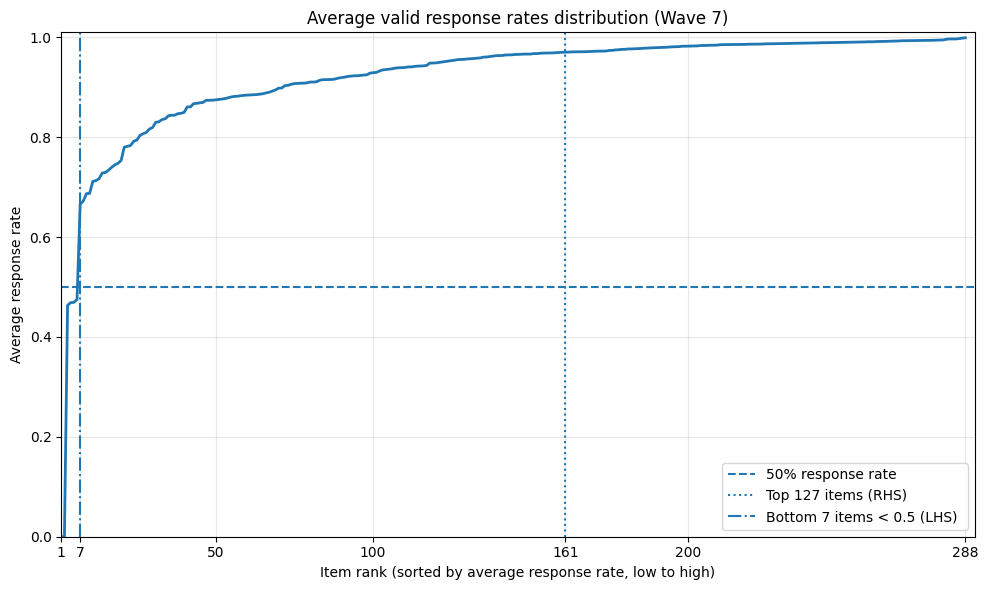

In [173]:
cutoff_rate = 0.5

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(x, avg_sorted.values, linewidth=2)

# horizontal line at 50%
ax.axhline(
    y=cutoff_rate,
    linestyle="--",
    linewidth=1.5,
    label="50% response rate"
)

# vertical line at top 127 items
ax.axvline(
    x=len(avg_sorted) - 127,
    linestyle=":",
    linewidth=1.5,
    label="Top 127 items (RHS)"
)

# first index where value < 0.5
cutoff_pos = (avg_sorted >= cutoff_rate).idxmax()

# convert to x-position (rank)
cutoff_x = avg_sorted.index.get_loc(cutoff_pos) + 1
cutoff_y = avg_sorted.loc[cutoff_pos]
print(cutoff_x)

# vertical line at top 127 items
ax.axvline(
    x=cutoff_x,
    linestyle="-.",
    linewidth=1.5,
    label=f"Bottom {cutoff_x} items < 0.5 (LHS) "
)

# axis labels
ax.set_xlabel("Item rank (sorted by average response rate, low to high)")
ax.set_ylabel("Average response rate")

# x-axis limits & ticks
ax.set_xlim(1, 291)
ax.set_xticks([1, cutoff_x, 50, 100, len(avg_sorted) - 127, 200, len(avg_sorted)])

# y-axis limits (optional but often nice)
ax.set_ylim(0, 1.01)

ax.legend()
ax.grid(alpha=0.3)
plt.title('Average valid response rates distribution (Wave 7)')
plt.tight_layout()
plt.savefig("./images/question_level_valid_response_rate.png", dpi = 300)
plt.show()


### Variable Type

In [6]:
wave_7 = pd.read_csv(f'./data/WVS_Wave_7.csv')

In [7]:
wave_7

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A062,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
0,AND,1,1,1,3,1,4,1,3,2,...,1,2,2,4,4,4,4,1,2,4
1,AND,1,1,1,4,1,4,1,1,2,...,1,2,2,4,4,4,4,2,2,4
2,AND,1,2,2,2,3,3,2,1,2,...,1,3,4,4,4,4,3,1,1,4
3,AND,1,1,1,4,2,4,2,2,-2,...,2,2,2,4,4,4,4,1,1,4
4,AND,1,1,1,3,1,3,2,2,2,...,2,2,2,4,4,4,4,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,1,3,1,1,1,2,2,1,3,...,1,2,2,3,3,2,1,2,2,3
97216,ZWE,1,1,2,1,1,1,2,1,2,...,4,1,1,4,1,2,2,1,2,4
97217,ZWE,1,3,2,2,2,2,3,3,3,...,2,1,1,2,2,2,2,1,2,4
97218,ZWE,1,2,2,1,1,1,4,1,2,...,1,1,1,1,3,1,1,1,2,3


In [33]:
df_127 = pd.read_csv(f'./data/127_items.csv')

In [34]:
df_127

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,C10,Important in life
1,Q2,Friends,A002,C10,Important in life
2,Q3,Leisure time,A003,C10,Important in life
3,Q4,Politics,A004,C10,Important in life
4,Q5,Work,A005,C10,Important in life
...,...,...,...,...,...
122,Q251,Democraticness in own country,E236,C32,Democraticness in own country
123,Q253,Respect for individual human rights nowadays,E124,C29,Respect for Human Rights
124,Q258,Continent; e.g. Europe Asia etc.,G062,C46,How close you feel
125,Q259,World,G063,C46,How close you feel


In [20]:
variable_equivalence_df

,Variable,Title,WVS7,WVS6,WVS5,WVS4,WVS3,WVS2,WVS1
0,A001,Important in life: Family,Q1,V4,V4,V4,V4,V5,NaN
1,A002,Important in life: Friends,Q2,V5,V5,V5,V5,V6,NaN
2,A003,Important in life: Leisure time,Q3,V6,V6,V6,V6,V7,NaN
3,A004,Important in life: Politics,Q4,V7,V7,V7,V7,V8,NaN
4,A005,Important in life: Work,Q5,V8,V8,V8,V8,V4,NaN
...,...,...,...,...,...,...,...,...,...
1043,Y023C,DIVORLIB- Welzel choice-3: Divorce acceptable,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB,I_DIVORLIB
1044,Y024,VOICE.- Welzel voice sub-index,VOICE,VOICE,VOICE,VOICE,VOICE,VOICE,VOICE
1045,Y024A,VOICE1- Welzel voice-1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1,I_VOICE1
1046,Y024B,VOICE2- Welzel voice-2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2,I_VOICE2


In [106]:
valid_response_rate_df[list(codes.keys())]

,E217,E218,E220,I001,I002,E234
Unnamed: 0,,,,,,
AND,1.000000,0.999004,0.995020,0.995020,1.000000,1.000000
ARG,0.984048,0.971087,0.961117,0.922233,0.980060,0.986042
ARM,0.992641,0.987735,0.969747,0.912510,0.991823,0.982829
AUS,0.991175,0.991726,0.990072,0.987314,0.990623,0.988417
BGD,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
...,...,...,...,...,...,...
USA,0.989985,0.988444,0.990370,0.987673,0.988444,0.986903
UZB,0.985600,0.988000,0.949600,0.950400,0.953600,0.973600
VEN,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000


**Categorical Items**

In [22]:
categorical_questions = [
    "Q7", "Q8", "Q9", "Q10", "Q11", "Q12", "Q13", "Q14", "Q15", "Q16",
    "Q17", "Q18", "Q19", "Q20", "Q21", "Q22", "Q23", "Q24", "Q25", "Q26",
    "Q42", "Q56", "Q57", "Q91", "Q92", "Q93", "Q94", "Q95", "Q96", "Q97",
    "Q98", "Q99", "Q100", "Q101", "Q102", "Q103", "Q104", "Q105", "Q111",
    "Q130", "Q139", "Q140", "Q141", "Q144", "Q145", "Q149", "Q150", "Q151",
    "Q152", "Q153", "Q154", "Q155", "Q156", "Q157", "Q165", "Q166", "Q167",
    "Q168", "Q173", "Q174", "Q175", "Q223", "Q260", "Q261", "Q262", "Q263",
    "Q264", "Q265", "Q266", "Q267", "Q268", "Q269", "Q270", "Q271", "Q272",
    "Q273", "Q274", "Q279", "Q280", "Q281", "Q282", "Q283", "Q284", "Q285",
    "Q286", "Q287", "Q289", "Q290"
]


In [25]:
CAT_COL = variable_equivalence_df[variable_equivalence_df['WVS7'].isin(categorical_questions)]['Variable']

In [26]:
CAT_COL

21      A027
22      A029
23      A030
24      A032
25      A034
        ... 
988     X040
991     X044
992     X045
1006    X051
1007    X052
Name: Variable, Length: 88, dtype: object

In [28]:
print(list(CAT_COL))

['A027', 'A029', 'A030', 'A032', 'A034', 'A035', 'A038', 'A039', 'A040', 'A041', 'A042', 'A098', 'A099', 'A100', 'A101', 'A102', 'A103', 'A104', 'A105', 'A106', 'A106B', 'A106C', 'A106D', 'A124_02', 'A124_03', 'A124_06', 'A124_07', 'A124_08', 'A124_09', 'A124_12', 'A124_42', 'A124_43', 'A165', 'B008', 'E001', 'E002', 'E003', 'E004', 'E005', 'E006', 'E012', 'E034', 'E143', 'E179WVS', 'E277', 'E279', 'E280', 'E281', 'F025', 'F034', 'F050', 'F051', 'F053', 'F054', 'F200', 'F201', 'G016', 'G026', 'G027', 'G027A', 'G027B', 'H003_01', 'H003_02', 'H003_03', 'H004', 'H005', 'H008_07', 'H008_08', 'V001A', 'V002A', 'V097EF', 'W003', 'W006E', 'X001', 'X002', 'X002_02A', 'X003', 'X007', 'X011', 'X013', 'X026', 'X028', 'X036E', 'X040', 'X044', 'X045', 'X051', 'X052']


In [42]:
for i in set(CAT_COL).intersection(df_127['code']):
    row = df_127[df_127['code'] == i]
    print(f"{i} {row['s_category'].iloc[0]}: {row['q_content'].iloc[0]}")


F034 Religious person: Religious person
H008_07 Freedom and Equality: Which more important
E006 Most important: second choice
E004 Aims of respondent: second choice
E001 Aims of country: first choice
H008_08 Freedom and securiy: Which more important
E277 Standard of Living: Standard of living comparing with your parents
E003 Aims of respondent: first choice
E034 Attitude to Society: Basic kinds of attitudes concerning society
A165 Trust Most People: Most people can be trusted
B008 Environment or Growth: Protecting environment vs. Economic growth
E005 Most important: first choice
G027A Immigrant: Respondent immigrant


Example:
A165.- Most people can be trusted
Generally speaking, would you say that most people can be trusted or that you need to be very careful in dealing with
people?
(A165)
1 Most people can be trusted 2 Need to be very careful

**Ordinal Items**

In [29]:
ordinal_questions = [
    "Q1", "Q2", "Q3", "Q4", "Q5", "Q6", "Q27", "Q28", "Q29", "Q30",
    "Q31", "Q32", "Q33", "Q34", "Q35", "Q36", "Q37", "Q38", "Q39", "Q40",
    "Q41", "Q43", "Q44", "Q45", "Q46", "Q47", "Q48", "Q49", "Q50", "Q51",
    "Q52", "Q53", "Q54", "Q55", "Q58", "Q59", "Q60", "Q61", "Q62", "Q63",
    "Q64", "Q65", "Q66", "Q67", "Q68", "Q69", "Q70", "Q71", "Q72", "Q73",
    "Q74", "Q75", "Q76", "Q77", "Q78", "Q79", "Q80", "Q81", "Q82", "Q83",
    "Q84", "Q85", "Q86", "Q87", "Q88", "Q89", "Q90", "Q106", "Q107", "Q108",
    "Q109", "Q110", "Q112", "Q113", "Q114", "Q115", "Q116", "Q117", "Q118",
    "Q119", "Q120", "Q121", "Q122", "Q123", "Q124", "Q125", "Q126", "Q127",
    "Q128", "Q129", "Q131", "Q132", "Q133", "Q134", "Q135", "Q136", "Q137",
    "Q138", "Q142", "Q143", "Q146", "Q147", "Q148", "Q158", "Q159", "Q160",
    "Q161", "Q162", "Q163", "Q164", "Q169", "Q170", "Q171", "Q172", "Q176",
    "Q177", "Q178", "Q179", "Q180", "Q181", "Q182", "Q183", "Q184", "Q185",
    "Q186", "Q187", "Q188", "Q189", "Q190", "Q191", "Q192", "Q193", "Q194",
    "Q195", "Q196", "Q197", "Q198", "Q199", "Q200", "Q201", "Q202", "Q203",
    "Q204", "Q205", "Q206", "Q207", "Q208", "Q209", "Q210", "Q211", "Q212",
    "Q213", "Q214", "Q215", "Q216", "Q217", "Q218", "Q219", "Q220", "Q221",
    "Q222", "Q224", "Q225", "Q226", "Q227", "Q228", "Q229", "Q230", "Q231",
    "Q232", "Q233", "Q234", "Q235", "Q236", "Q237", "Q238", "Q239", "Q240",
    "Q241", "Q242", "Q243", "Q244", "Q245", "Q246", "Q247", "Q248", "Q249",
    "Q250", "Q251", "Q252", "Q253", "Q254", "Q255", "Q256", "Q257", "Q258",
    "Q259", "Q275", "Q276", "Q277", "Q278", "Q288"
]


In [30]:
ORD_COL = variable_equivalence_df[variable_equivalence_df['WVS7'].isin(ordinal_questions)]['Variable']

In [31]:
ORD_COL

0           A001
1           A002
2           A003
3           A004
4           A005
         ...    
952    V004AF_01
953    V004AM_01
957     W002A_01
979     X025A_01
995     X047_WVS
Name: Variable, Length: 202, dtype: object

In [32]:
print(list(ORD_COL))

['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008', 'A009', 'A062', 'A170', 'A173', 'C001_01', 'C002_01', 'C006', 'C038', 'C039', 'C041', 'D001_B', 'D026_03', 'D026_05', 'D054', 'D057', 'D059', 'D060', 'D061', 'D066_01', 'D078', 'D081', 'E015', 'E016', 'E018', 'E023', 'E025', 'E026', 'E027', 'E028', 'E033', 'E035', 'E036', 'E037', 'E039', 'E040', 'E069_01', 'E069_02', 'E069_04', 'E069_05', 'E069_06', 'E069_07', 'E069_08', 'E069_10', 'E069_11', 'E069_12', 'E069_13', 'E069_14', 'E069_15', 'E069_17', 'E069_18A', 'E069_19', 'E069_20', 'E069_40', 'E069_41', 'E069_45', 'E069_54', 'E069_61', 'E069_62', 'E069_63', 'E069_64', 'E069_65', 'E111_01', 'E114', 'E115', 'E116', 'E117', 'E117B', 'E124', 'E217', 'E218', 'E220', 'E224', 'E225', 'E226', 'E227', 'E228', 'E229', 'E233', 'E233A', 'E233B', 'E234', 'E235', 'E236', 'E248B', 'E253B', 'E254B', 'E258B', 'E259B', 'E260B', 'E261B', 'E262B', 'E263', 'E264', 'E265_01', 'E265_02', 'E265_03', 'E265_04', 'E265_05', 'E265_06', 'E265_07', 'E265_08', '

In [45]:
for i in set(ORD_COL).intersection(df_127['code']):
    row = df_127[df_127['code'] == i]
    print(f"{i} {row['s_category'].iloc[0]}: {row['q_content'].iloc[0]}")


H008_01 Frequency you/family (last 12 month): Gone without enough food to eat
G058 Effects of immigrants on the development of [your country]: Help poor people establish new lives
D078 Values: Men make better business executives than women do
E117B Political system: Having a system governed by religious law in which there are no political parties or elections
E260B Information source: Mobile phone (B)
E069_12 Confidence: The Political Parties
E069_05 Confidence: Labour Unions
E069_54 Confidence: Universities
E259B Information source: Radio news (B)
E018 Future changes: Greater respect for authority
E268 Scale corruption in [my country]: pay a bribe give a gift do a favor to other to get things
H008_04 Frequency you/family (last 12 month): Gone without a cash income
A002 Important in life: Friends
A004 Important in life: Politics
C039 Duty and Rights: Work is a duty towards society
F028 Religious Service Attendance: How often do you attend religious services
F114D Justifiable: Violence 

In [48]:
print(list(set(ORD_COL).intersection(df_127['code'])))

['H008_01', 'G058', 'D078', 'E117B', 'E260B', 'E069_12', 'E069_05', 'E069_54', 'E259B', 'E018', 'E268', 'H008_04', 'A002', 'A004', 'C039', 'F028', 'F114D', 'F117', 'F114C', 'E287', 'F123', 'G007_36_B', 'G063', 'A009', 'D026_05', 'E025', 'E289', 'E039', 'F114B', 'A003', 'D057', 'A005', 'E261B', 'E069_41', 'D060', 'F120', 'E035', 'E069_14', 'E069_40', 'E023', 'H008_02', 'G007_35_B', 'E117', 'E114', 'C038', 'F121', 'E069_13', 'C006', 'F144_02', 'C041', 'E069_15', 'E235', 'E069_01', 'G062', 'E015', 'E115', 'D061', 'G007_18_B', 'E028', 'D059', 'F116', 'E027', 'E069_08', 'E248B', 'E069_10', 'H008_09', 'A008', 'F114A', 'E227', 'E224', 'E016', 'H001', 'E040', 'E225', 'F122', 'E036', 'E233A', 'H006_01', 'D001_B', 'F028B', 'E233', 'E262B', 'F206', 'E124', 'D066_01', 'E258B', 'E236', 'H008_03', 'E226', 'A006', 'H006_02', 'E069_07', 'F202', 'G052', 'E286', 'E229', 'A001', 'G007_34_B', 'E037', 'A170', 'C002_01', 'C001_01', 'E254B', 'E069_04', 'D054', 'E233B', 'E026', 'D026_03', 'A173', 'A062', 'G00

Example: 
F202.- Whenever science and religion conflict, religion is always right
Please tell us if you strongly agree, agree, disagree, or strongly disagree with the following statements: Whenever science and religion conflict, religion is always right
(F202)
1 Strongly agree
2 Agree
3 Disagree
4 Strongly disagree

For 'E224' to 'E233B', 'E235', 'E236', we need to treat 0 as negative because 0 is the spontaneous response recorded.

In [149]:
wave_7.columns

Index(['COUNTRY_ALPHA', 'A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008',
       'A009', 'A062',
       ...
       'H001', 'H006_01', 'H006_02', 'H008_01', 'H008_02', 'H008_03',
       'H008_04', 'H008_07', 'H008_08', 'H008_09'],
      dtype='object', length=128)

In [150]:
items_only_in_a = list(set(wave_7.columns) - set(ORD_COL + CAT_COL))

In [151]:
items_only_in_a

['COUNTRY_ALPHA']

In [152]:
temp_items = ['E224', 'E225', 'E226', 'E227', 'E228', 'E229', 'E233', 'E233A', 'E233B',  'E235', 'E236']
overlapping_items = list(set(temp_items).intersection(set(ORD_COL)))
wave_7[overlapping_items] = wave_7[overlapping_items].replace(0, -1)

#### Encoding

In [ ]:
# col = wave_7['H008_07'].replace({v: np.nan for v in wave_7['H008_07'].unique() if v < 0})
# pd.get_dummies(col, prefix='H008_07').astype(float)

,H008_07_1.0,H008_07_2.0
0,1.0,0.0
1,0.0,1.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
97215,0.0,1.0
97216,1.0,0.0
97217,1.0,0.0
97218,1.0,0.0


In [ ]:
# def encode_by_item(df_data):
#     """
#     Use all response from Wave 7
#     For each item, one-hot encode non-negative values,
#     Record the encoded features
#     """
#     df_encoded_list = []
#     category_map = {}

#     for item in CAT_COL:
#         # Treat negatives as missing
#         col = df_data[item].replace({v: np.nan for v in df_data[item].unique() if v < 0})

#         categories = sorted(col.dropna().unique())
#         category_map[item] = categories

#         df_item_encoded = pd.get_dummies(col, prefix=item).astype(float)

#         # Append to the list
#         df_encoded_list.append(df_item_encoded)

#     df_updated = df_data.drop(columns=CAT_COL)

#     # Concatenate all encoded columns
#     df_encoded = pd.concat(df_encoded_list, axis=1)
#     df_updated = pd.concat([df_updated, df_encoded], axis=1)

#     return category_map, df_updated

In [ ]:
# category_map, wave_7 = encode_by_item(wave_7)

In [ ]:
# category_map

{'A165': [np.float64(1.0), np.float64(2.0)],
 'B008': [np.float64(1.0), np.float64(2.0), np.float64(3.0)],
 'C001': [np.float64(1.0), np.float64(2.0), np.float64(3.0)],
 'C002': [np.float64(1.0), np.float64(2.0), np.float64(3.0)],
 'E001': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E002': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E003': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E004': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E005': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E006': [np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0)],
 'E034': [np.float64(1.0), np.float64(2.0), np.float64(3.0)],
 'E277': [np.float64(1.0), np.float64(2.0), np.float64(3.0)],
 'F025': [np.float64(0.0),
  np.float64(1.0),
  np.float64(2.0),
  np.float64(3.0),
  np.float64(4.0),
  np.float64(5.0),
  np.float64(6.0),
  np.float64(7.0),
  np.float6

In [ ]:
# wave_7

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A027,...,F025_6.0,F025_7.0,F025_8.0,F025_9.0,G027A_1.0,G027A_2.0,H008_07_1.0,H008_07_2.0,H008_08_1.0,H008_08_2.0
0,AND,1,1,1,3,1,4,1,3,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
1,AND,1,1,1,4,1,4,1,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
2,AND,1,2,2,2,3,3,2,1,0,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
3,AND,1,1,1,4,2,4,2,2,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
4,AND,1,1,1,3,1,3,2,2,1,...,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,1,3,1,1,1,2,2,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
97216,ZWE,1,1,2,1,1,1,2,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
97217,ZWE,1,3,2,2,2,2,3,3,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
97218,ZWE,1,2,2,1,1,1,4,1,1,...,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0


In [ ]:
# with open('./data/category_map.pkl','wb') as f:
#     pickle.dump(category_map, f)

#### Standardization

In [153]:
from sklearn.preprocessing import MinMaxScaler

In [154]:
def scale_by_item(df_data, itemlist):
    """
    Use all response from Wave 7
    For each item, select non-negative values, fit and transform the scaler
    Record the fitted scaler for item
    Each scaled item is added to the feature matrix as df_matrix[item_scaled]
    """

    item_scaler = {}
    for item in itemlist:
        # select non-negative values
        non_negative_mask = df_data[item] >= 0
        item_fmatrix = df_data[non_negative_mask][[item]]

        scaler = MinMaxScaler()
        item_fmatrix_scaled = scaler.fit_transform(item_fmatrix).flatten()
        item_scaler[item] = scaler # record the scaler for later use to apply to LLM

        # turn type to float
        df_data[item] = df_data[item].astype(float)
        # negative values remain as it is and positive values are scaled
        df_data.loc[non_negative_mask, item] = item_fmatrix_scaled

    return item_scaler

In [155]:
itemlist = wave_7.columns[1:]
itemlist

Index(['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008', 'A009', 'A062',
       'A165',
       ...
       'H001', 'H006_01', 'H006_02', 'H008_01', 'H008_02', 'H008_03',
       'H008_04', 'H008_07', 'H008_08', 'H008_09'],
      dtype='object', length=127)

In [156]:
wave_7

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A062,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
0,AND,1,1,1,3,1,4,1,3,2,...,1,2,2,4,4,4,4,1,2,4
1,AND,1,1,1,4,1,4,1,1,2,...,1,2,2,4,4,4,4,2,2,4
2,AND,1,2,2,2,3,3,2,1,2,...,1,3,4,4,4,4,3,1,1,4
3,AND,1,1,1,4,2,4,2,2,-2,...,2,2,2,4,4,4,4,1,1,4
4,AND,1,1,1,3,1,3,2,2,2,...,2,2,2,4,4,4,4,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,1,3,1,1,1,2,2,1,3,...,1,2,2,3,3,2,1,2,2,3
97216,ZWE,1,1,2,1,1,1,2,1,2,...,4,1,1,4,1,2,2,1,2,4
97217,ZWE,1,3,2,2,2,2,3,3,3,...,2,1,1,2,2,2,2,1,2,4
97218,ZWE,1,2,2,1,1,1,4,1,2,...,1,1,1,1,3,1,1,1,2,3


In [ ]:
item_scaler = scale_by_item(wave_7, itemlist)
item_scaler

We realized a problem with the current approach the revised the scalers using the codes below: 

In [161]:
with open('./data/wvs_scaler_mapping.json', 'r') as f:
    raw = json.load(f)

In [164]:
from sklearn.preprocessing import MinMaxScaler
import numpy as np

# Define all scale ranges
scale_ranges = {
    'scale_0_2': (0, 2),
    'scale_1_2': (1, 2),
    'scale_1_3': (1, 3),
    'scale_1_4': (1, 4),
    'scale_1_5': (1, 5),
    'scale_1_7': (1, 7),
    'scale_1_8': (1, 8),
    'scale_1_10': (1, 10),
}

# Create and fit scalers for each scale range using virtual datasets
scalers = {}
for scale_name, (min_val, max_val) in scale_ranges.items():
    # Create virtual dataset with all possible integer values in the range
    virtual_data = np.arange(min_val, max_val + 1).reshape(-1, 1)
    
    # Fit MinMaxScaler
    scaler = MinMaxScaler(feature_range=(0, 1))
    scaler.fit(virtual_data)
    scalers[scale_name] = scaler

# Map each question code to its appropriate scaler
question_to_scaler = {
    # Scale 1-4 (61 questions)
    **{f'Q{i}': 'scale_1_4' for i in [1, 2, 3, 4, 5, 6]},  # Q1-Q6: Importance in life
    **{f'Q{i}': 'scale_1_4' for i in range(27, 33)},  # Q27-Q32: Agreement statements
    'Q46': 'scale_1_4',  # Happiness
    **{f'Q{i}': 'scale_1_4' for i in range(51, 56)},  # Q51-Q55: Trust in groups
    **{f'Q{i}': 'scale_1_4' for i in range(58, 64)},  # Q58-Q63: Agreement statements
    **{f'Q{i}': 'scale_1_4' for i in range(64, 90)},  # Q64-Q89: Confidence in institutions
    'Q131': 'scale_1_4',  # Interest in politics
    **{f'Q{i}': 'scale_1_4' for i in range(142, 144)},  # Q142-Q143: Politics
    **{f'Q{i}': 'scale_1_4' for i in range(152, 158)},  # Q152-Q157: Priority rankings
    **{f'Q{i}': 'scale_1_4' for i in [169, 170]},  # Q169-Q170: Religion
    'Q199': 'scale_1_4',  # Government respect
    **{f'Q{i}': 'scale_1_4' for i in range(235, 240)},  # Q235-Q239: Political systems
    'Q253': 'scale_1_4',  # Geographic closeness
    **{f'Q{i}': 'scale_1_4' for i in range(255, 260)},  # Q255-Q259: Security & hardship
    
    # Scale 1-10 (40 questions)
    **{f'Q{i}': 'scale_1_10' for i in range(48, 51)},  # Q48-Q50: Freedom, satisfaction
    **{f'Q{i}': 'scale_1_10' for i in range(106, 113)},  # Q106-Q112: Economic/political views
    'Q176': 'scale_1_10',  # Certainty
    **{f'Q{i}': 'scale_1_10' for i in range(177, 196)},  # Q177-Q195: Justifiability
    **{f'Q{i}': 'scale_1_10' for i in range(241, 252)},  # Q241-Q251: Democracy
    
    # Scale 1-5 (19 questions)
    **{f'Q{i}': 'scale_1_5' for i in range(33, 42)},  # Q33-Q41: Social statements
    'Q47': 'scale_1_5',  # Health
    'Q121': 'scale_1_5',  # Immigration impact
    **{f'Q{i}': 'scale_1_5' for i in range(201, 209)},  # Q201-Q208: Information sources
    
    # Scale 1-3 (16 questions)
    **{f'Q{i}': 'scale_1_3' for i in range(42, 46)},  # Q42-Q45: Future changes
    'Q56': 'scale_1_3',  # Standard of living
    'Q111': 'scale_1_3',  # Environment vs economy
    'Q173': 'scale_1_3',  # Religious identity
    'Q200': 'scale_1_3',  # Political discussion
    **{f'Q{i}': 'scale_1_3' for i in range(209, 217)},  # Q209-Q216: Political action
    
    # Scale 1-2 (4 questions)
    'Q57': 'scale_1_2',  # Trust
    'Q149': 'scale_1_2',  # Freedom vs Equality
    'Q150': 'scale_1_2',  # Freedom vs Security
    'Q263': 'scale_1_2',  # Immigrant status
    
    # Scale 0-2 (8 questions)
    **{f'Q{i}': 'scale_0_2' for i in range(122, 130)},  # Q122-Q129: Immigration effects
    
    # Scale 1-7 (1 question)
    'Q171': 'scale_1_7',  # Religious attendance
    
    # Scale 1-8 (1 question)
    'Q172': 'scale_1_8',  # Prayer frequency
}

# Helper functions for normalization
def normalize_response(question_code, response_value):
    """Normalize a response value for a given question code."""
    if question_code not in question_to_scaler:
        raise ValueError(f"Unknown question code: {question_code}")
    
    scaler_name = question_to_scaler[question_code]
    scaler = scalers[scaler_name]
    normalized = scaler.transform([[response_value]])[0][0]
    return normalized

def denormalize_response(question_code, normalized_value):
    """Denormalize a value back to the original scale."""
    if question_code not in question_to_scaler:
        raise ValueError(f"Unknown question code: {question_code}")
    
    scaler_name = question_to_scaler[question_code]
    scaler = scalers[scaler_name]
    denormalized = scaler.inverse_transform([[normalized_value]])[0][0]
    return denormalized

# Display summary
print(f"Created {len(scalers)} scalers for scale ranges: {list(scalers.keys())}")
print(f"Mapped {len(question_to_scaler)} questions to scalers")
print(f"\nExample usage:")
print(f"  normalize_response('Q1', 1) = {normalize_response('Q1', 1):.3f}")
print(f"  normalize_response('Q177', 5) = {normalize_response('Q177', 5):.3f}")


Created 8 scalers for scale ranges: ['scale_0_2', 'scale_1_2', 'scale_1_3', 'scale_1_4', 'scale_1_5', 'scale_1_7', 'scale_1_8', 'scale_1_10']
Mapped 162 questions to scalers

Example usage:
  normalize_response('Q1', 1) = 0.000
  normalize_response('Q177', 5) = 0.444


In [171]:
question_to_scaler['Q33_3'] = 'scale_1_3'
question_to_scaler['Q34_3'] = 'scale_1_3'
question_to_scaler['Q35_3'] = 'scale_1_3'

In [172]:
question_to_scaler

{'Q1': 'scale_1_4',
 'Q2': 'scale_1_4',
 'Q3': 'scale_1_4',
 'Q4': 'scale_1_4',
 'Q5': 'scale_1_4',
 'Q6': 'scale_1_4',
 'Q27': 'scale_1_4',
 'Q28': 'scale_1_4',
 'Q29': 'scale_1_4',
 'Q30': 'scale_1_4',
 'Q31': 'scale_1_4',
 'Q32': 'scale_1_4',
 'Q46': 'scale_1_4',
 'Q51': 'scale_1_4',
 'Q52': 'scale_1_4',
 'Q53': 'scale_1_4',
 'Q54': 'scale_1_4',
 'Q55': 'scale_1_4',
 'Q58': 'scale_1_4',
 'Q59': 'scale_1_4',
 'Q60': 'scale_1_4',
 'Q61': 'scale_1_4',
 'Q62': 'scale_1_4',
 'Q63': 'scale_1_4',
 'Q64': 'scale_1_4',
 'Q65': 'scale_1_4',
 'Q66': 'scale_1_4',
 'Q67': 'scale_1_4',
 'Q68': 'scale_1_4',
 'Q69': 'scale_1_4',
 'Q70': 'scale_1_4',
 'Q71': 'scale_1_4',
 'Q72': 'scale_1_4',
 'Q73': 'scale_1_4',
 'Q74': 'scale_1_4',
 'Q75': 'scale_1_4',
 'Q76': 'scale_1_4',
 'Q77': 'scale_1_4',
 'Q78': 'scale_1_4',
 'Q79': 'scale_1_4',
 'Q80': 'scale_1_4',
 'Q81': 'scale_1_4',
 'Q82': 'scale_1_4',
 'Q83': 'scale_1_4',
 'Q84': 'scale_1_4',
 'Q85': 'scale_1_4',
 'Q86': 'scale_1_4',
 'Q87': 'scale_1_4'

In [173]:
df_127code = pd.read_csv('./data/127_items.csv')

In [174]:
df_127code

,survey_q,q_content,code,set,s_category
0,Q1,Family,A001,C10,Important in life
1,Q2,Friends,A002,C10,Important in life
2,Q3,Leisure time,A003,C10,Important in life
3,Q4,Politics,A004,C10,Important in life
4,Q5,Work,A005,C10,Important in life
...,...,...,...,...,...
122,Q251,Democraticness in own country,E236,C32,Democraticness in own country
123,Q253,Respect for individual human rights nowadays,E124,C29,Respect for Human Rights
124,Q258,Continent; e.g. Europe Asia etc.,G062,C46,How close you feel
125,Q259,World,G063,C46,How close you feel


In [175]:
scalers

{'scale_0_2': MinMaxScaler(),
 'scale_1_2': MinMaxScaler(),
 'scale_1_3': MinMaxScaler(),
 'scale_1_4': MinMaxScaler(),
 'scale_1_5': MinMaxScaler(),
 'scale_1_7': MinMaxScaler(),
 'scale_1_8': MinMaxScaler(),
 'scale_1_10': MinMaxScaler()}

In [176]:
# Assuming df_127code, scalers, and question_to_scaler are already defined

# Map each code to the correct scaler
item_scalers = {
    row['code']: scalers[question_to_scaler[row['survey_q']]]
    for _, row in df_127code.iterrows()
}

# Example output
print(item_scalers)


{'A001': MinMaxScaler(), 'A002': MinMaxScaler(), 'A003': MinMaxScaler(), 'A004': MinMaxScaler(), 'A005': MinMaxScaler(), 'A006': MinMaxScaler(), 'D054': MinMaxScaler(), 'D061': MinMaxScaler(), 'D059': MinMaxScaler(), 'D060': MinMaxScaler(), 'D078': MinMaxScaler(), 'D057': MinMaxScaler(), 'C001_01': MinMaxScaler(), 'C001': MinMaxScaler(), 'C002': MinMaxScaler(), 'C002_01': MinMaxScaler(), 'D066_01': MinMaxScaler(), 'D066_B': MinMaxScaler(), 'D026_03': MinMaxScaler(), 'D026_05': MinMaxScaler(), 'C038': MinMaxScaler(), 'C039': MinMaxScaler(), 'C041': MinMaxScaler(), 'E034': MinMaxScaler(), 'E015': MinMaxScaler(), 'E016': MinMaxScaler(), 'E018': MinMaxScaler(), 'A008': MinMaxScaler(), 'A009': MinMaxScaler(), 'A173': MinMaxScaler(), 'A170': MinMaxScaler(), 'C006': MinMaxScaler(), 'H008_01': MinMaxScaler(), 'H008_02': MinMaxScaler(), 'H008_03': MinMaxScaler(), 'H008_04': MinMaxScaler(), 'H008_09': MinMaxScaler(), 'E277': MinMaxScaler(), 'A165': MinMaxScaler(), 'D001_B': MinMaxScaler(), 'G007

In [113]:
item_scaler = scale_by_item(wave_7, itemlist)

In [114]:
item_scaler

{'A001': MinMaxScaler(),
 'A002': MinMaxScaler(),
 'A003': MinMaxScaler(),
 'A004': MinMaxScaler(),
 'A005': MinMaxScaler(),
 'A006': MinMaxScaler(),
 'A008': MinMaxScaler(),
 'A009': MinMaxScaler(),
 'A062': MinMaxScaler(),
 'A165': MinMaxScaler(),
 'A170': MinMaxScaler(),
 'A173': MinMaxScaler(),
 'B008': MinMaxScaler(),
 'C001': MinMaxScaler(),
 'C001_01': MinMaxScaler(),
 'C002': MinMaxScaler(),
 'C002_01': MinMaxScaler(),
 'C006': MinMaxScaler(),
 'C038': MinMaxScaler(),
 'C039': MinMaxScaler(),
 'C041': MinMaxScaler(),
 'D001_B': MinMaxScaler(),
 'D026_03': MinMaxScaler(),
 'D026_05': MinMaxScaler(),
 'D054': MinMaxScaler(),
 'D057': MinMaxScaler(),
 'D059': MinMaxScaler(),
 'D060': MinMaxScaler(),
 'D061': MinMaxScaler(),
 'D066_B': MinMaxScaler(),
 'D066_01': MinMaxScaler(),
 'D078': MinMaxScaler(),
 'E001': MinMaxScaler(),
 'E003': MinMaxScaler(),
 'E004': MinMaxScaler(),
 'E005': MinMaxScaler(),
 'E006': MinMaxScaler(),
 'E015': MinMaxScaler(),
 'E016': MinMaxScaler(),
 'E018

In [204]:
with open('./data/item_scaler_v3.pkl','wb') as f:
    pickle.dump(item_scalers, f)

In [205]:
wave_7

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A062,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
0,AND,1,1,1,3,1,4,1,3,2,...,1,2,2,4,4,4,4,1,2,4
1,AND,1,1,1,4,1,4,1,1,2,...,1,2,2,4,4,4,4,2,2,4
2,AND,1,2,2,2,3,3,2,1,2,...,1,3,4,4,4,4,3,1,1,4
3,AND,1,1,1,4,2,4,2,2,-2,...,2,2,2,4,4,4,4,1,1,4
4,AND,1,1,1,3,1,3,2,2,2,...,2,2,2,4,4,4,4,1,2,4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,1,3,1,1,1,2,2,1,3,...,1,2,2,3,3,2,1,2,2,3
97216,ZWE,1,1,2,1,1,1,2,1,2,...,4,1,1,4,1,2,2,1,2,4
97217,ZWE,1,3,2,2,2,2,3,3,3,...,2,1,1,2,2,2,2,1,2,4
97218,ZWE,1,2,2,1,1,1,4,1,2,...,1,1,1,1,3,1,1,1,2,3


In [206]:
transformed_df = pd.DataFrame(index=wave_7.index)

for col in wave_7.columns:
    if col in item_scalers:
        # Transform column using its scaler
        transformed_df[col] = item_scalers[col].transform(wave_7[[col]])
    else:
        # Keep original if no scaler assigned
        transformed_df[col] = wave_7[col]

transformed_df

/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/ai_agents/lib/python3.13/site-packages/sklearn/utils/validation.py:2742: UserWarning: X has feature names, but MinMaxScaler was fitted without feature names
  warnings.warn(
/opt/anaconda3/envs/ai_agents/

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A062,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
0,AND,0.0,0.000000,0.000000,0.666667,0.000000,1.000000,0.000000,0.50,0.5,...,0.000000,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,1.0,1.000000
1,AND,0.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00,0.5,...,0.000000,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000
2,AND,0.0,0.333333,0.333333,0.333333,0.666667,0.666667,0.333333,0.00,0.5,...,0.000000,0.666667,1.000000,1.000000,1.000000,1.000000,0.666667,0.0,0.0,1.000000
3,AND,0.0,0.000000,0.000000,1.000000,0.333333,1.000000,0.333333,0.25,-1.5,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000
4,AND,0.0,0.000000,0.000000,0.666667,0.000000,0.666667,0.333333,0.25,0.5,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,0.0,0.666667,0.000000,0.000000,0.000000,0.333333,0.333333,0.00,1.0,...,0.000000,0.333333,0.333333,0.666667,0.666667,0.333333,0.000000,1.0,1.0,0.666667
97216,ZWE,0.0,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.00,0.5,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.333333,0.333333,0.0,1.0,1.000000
97217,ZWE,0.0,0.666667,0.333333,0.333333,0.333333,0.333333,0.666667,0.50,1.0,...,0.333333,0.000000,0.000000,0.333333,0.333333,0.333333,0.333333,0.0,1.0,1.000000
97218,ZWE,0.0,0.333333,0.333333,0.000000,0.000000,0.000000,1.000000,0.00,0.5,...,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.0,1.0,0.666667


In [208]:
transformed_df.describe()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
count,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,...,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000
mean,0.035463,0.231736,0.253940,0.516797,0.169852,0.315683,0.275907,0.294093,0.574465,0.713248,...,0.326428,0.314541,0.231996,0.821096,0.805513,0.772187,0.715741,0.365604,0.631876,0.892402
std,0.135828,0.261950,0.283897,0.364329,0.316742,0.393954,0.261052,0.229046,0.399371,0.569273,...,0.295244,0.548499,0.629073,0.321132,0.327894,0.351453,0.367844,0.680808,0.660651,0.295638
min,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-1.500000,-3.000000,-3.000000,...,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-2.000000,-6.000000,-6.000000,-2.000000
25%,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.250000,0.500000,0.000000,...,0.000000,0.000000,0.000000,0.666667,0.666667,0.666667,0.333333,0.000000,0.000000,1.000000
50%,0.000000,0.333333,0.333333,0.666667,0.000000,0.333333,0.333333,0.250000,0.500000,1.000000,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,1.000000
75%,0.000000,0.333333,0.333333,0.666667,0.333333,0.666667,0.333333,0.500000,1.000000,1.000000,...,0.333333,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [209]:
transformed_df.to_csv(f'./data/WVS_Wave_7_processed_v3.csv', index=False)

#### Interpolate Negative Values

We interpolate negative values using the mean of all non-negative values of that country's responses. 

In [210]:
wave_7 = pd.read_csv(f'./data/WVS_Wave_7_processed_v3.csv')

In [ ]:
# wave_7[ORD_COL].describe()

,A001,A002,A003,A004,A005,A006,A008,A009,A027,A029,...,G062,G063,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_09
count,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,...,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000
mean,0.037714,0.236310,0.261599,0.533833,0.187938,0.329591,0.284684,0.297490,0.775095,0.432461,...,0.472582,0.495753,0.335774,0.400006,0.367126,0.831855,0.817129,0.785157,0.727422,0.908169
std,0.121570,0.247471,0.261628,0.323451,0.262537,0.363542,0.234812,0.218578,0.416669,0.492768,...,0.316532,0.325659,0.269751,0.362882,0.362890,0.282419,0.289129,0.308679,0.335154,0.230179
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.250000,1.000000,0.000000,...,0.333333,0.333333,0.000000,0.000000,0.000000,0.666667,0.666667,0.666667,0.333333,1.000000
50%,0.000000,0.333333,0.333333,0.666667,0.000000,0.333333,0.333333,0.250000,1.000000,0.000000,...,0.333333,0.495753,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.000000,0.333333,0.333333,0.666667,0.333333,0.666667,0.333333,0.500000,1.000000,1.000000,...,0.666667,0.666667,0.333333,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [ ]:
# item_mean_map = wave_7[ORD_COL].mask(wave_7[ORD_COL] < 0).mean().to_dict()

In [ ]:
# for col in ORD_COL:
#     wave_7[col] = wave_7[col].mask(wave_7[col] < 0, item_mean_map[col])

In [ ]:
# wave_7[ORD_COL].describe()

,A001,A002,A003,A004,A005,A006,A008,A009,A027,A029,...,G062,G063,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_09
count,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,...,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000,97220.000000
mean,0.037714,0.236310,0.261599,0.533833,0.187938,0.329591,0.284684,0.297490,0.775095,0.432461,...,0.472582,0.495753,0.335774,0.400006,0.367126,0.831855,0.817129,0.785157,0.727422,0.908169
std,0.121570,0.247471,0.261628,0.323451,0.262537,0.363542,0.234812,0.218578,0.416669,0.492768,...,0.316532,0.325659,0.269751,0.362882,0.362890,0.282419,0.289129,0.308679,0.335154,0.230179
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.333333,0.000000,0.000000,0.000000,0.250000,1.000000,0.000000,...,0.333333,0.333333,0.000000,0.000000,0.000000,0.666667,0.666667,0.666667,0.333333,1.000000
50%,0.000000,0.333333,0.333333,0.666667,0.000000,0.333333,0.333333,0.250000,1.000000,0.000000,...,0.333333,0.495753,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,1.000000
75%,0.000000,0.333333,0.333333,0.666667,0.333333,0.666667,0.333333,0.500000,1.000000,1.000000,...,0.666667,0.666667,0.333333,0.666667,0.666667,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


**Update:** We decide to use country-item level mean. 

In [211]:
wave_7[wave_7['COUNTRY_ALPHA'] == 'CHN'].describe()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
count,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,...,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.000000,3036.00000,3036.000000,3036.000000
mean,0.045674,0.240338,0.354963,0.441151,0.233311,0.734300,0.283158,0.302125,0.636858,0.315876,...,0.276570,0.409530,0.288757,0.959816,0.890426,0.889657,0.870334,0.63307,0.920619,0.955094
std,0.136239,0.211918,0.256150,0.310437,0.274330,0.305722,0.211530,0.234355,0.305569,0.568264,...,0.194841,0.368410,0.345771,0.147699,0.228320,0.241291,0.270022,0.55452,0.335622,0.174096
min,-1.000000,-1.000000,-2.000000,-2.000000,-2.000000,-1.000000,-1.000000,-0.750000,-1.500000,-3.000000,...,-1.000000,-2.000000,-2.000000,-1.000000,-1.000000,-1.000000,-1.000000,-3.00000,-3.000000,-1.000000
25%,0.000000,0.000000,0.333333,0.333333,0.000000,0.666667,0.000000,0.000000,0.500000,0.000000,...,0.000000,0.333333,0.000000,1.000000,1.000000,1.000000,1.000000,0.00000,1.000000,1.000000
50%,0.000000,0.333333,0.333333,0.333333,0.333333,0.666667,0.333333,0.250000,0.500000,0.000000,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
75%,0.000000,0.333333,0.666667,0.666667,0.333333,1.000000,0.333333,0.500000,1.000000,1.000000,...,0.333333,0.666667,0.333333,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000


In [212]:
itemlist = wave_7.columns[1:]

In [213]:
itemlist

Index(['A001', 'A002', 'A003', 'A004', 'A005', 'A006', 'A008', 'A009', 'A062',
       'A165',
       ...
       'H001', 'H006_01', 'H006_02', 'H008_01', 'H008_02', 'H008_03',
       'H008_04', 'H008_07', 'H008_08', 'H008_09'],
      dtype='object', length=127)

In [214]:
df_valid = wave_7.copy()

for col in itemlist:
    df_valid[col] = df_valid[col].where(df_valid[col] >= 0)

country_means = df_valid.groupby('COUNTRY_ALPHA')[itemlist].mean()

In [215]:
country_means

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
COUNTRY_ALPHA,,,,,,,,,,,,,,,,,,,,,
AND,0.038513,0.178619,0.140438,0.646707,0.175316,0.655023,0.236720,0.227590,0.585204,0.744256,...,0.095713,0.483034,0.450568,0.955755,0.967066,0.966034,0.854437,0.337662,0.634000,0.963297
ARG,0.030575,0.180459,0.269937,0.602398,0.156135,0.464646,0.270600,0.288462,0.625253,0.793067,...,0.475524,0.507645,0.525600,0.903859,0.627706,0.866333,0.808951,0.358358,0.635271,0.933333
ARM,0.017716,0.253682,0.301049,0.570724,0.114754,0.133169,0.228909,0.434943,0.366995,0.918919,...,0.467875,0.353152,0.268603,0.869447,0.952107,0.826492,0.715261,0.552453,0.821963,0.961811
AUS,0.036791,0.159872,0.215452,0.470611,0.331797,0.632576,0.260942,0.263781,0.525028,0.459821,...,0.336113,0.584302,0.606899,0.944630,0.822494,0.898236,0.854283,0.232532,0.435722,0.982935
BGD,0.005000,0.356187,0.397253,0.692110,0.074198,0.022556,0.278333,0.321250,0.670837,0.870726,...,0.283848,0.455725,0.243688,0.826099,0.872803,0.647190,0.586139,0.259849,0.725293,0.900341
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
USA,0.043836,0.210221,0.243351,0.458042,0.284975,0.431783,0.294049,0.275126,0.182722,0.602629,...,0.420183,0.611737,0.619924,0.868367,0.824106,0.798944,0.786636,0.233281,0.290588,0.957463
UZB,0.027200,0.310345,0.410504,0.360886,0.177760,0.234175,0.176024,0.232745,0.538907,0.652893,...,0.190437,0.383333,0.259289,0.799944,0.895031,0.846967,0.661471,0.385847,0.577703,0.916312
VEN,0.057983,0.290756,0.234734,0.654342,0.147619,0.298599,0.290476,0.260504,0.592437,0.857983,...,0.454062,0.290756,0.285714,0.434174,0.709244,0.469468,0.318487,0.269748,0.498319,0.791317


In [216]:
df_filled = wave_7.copy()

for col in itemlist:
    df_filled[col] = np.where(
        wave_7[col] < 0,
        wave_7['COUNTRY_ALPHA'].map(country_means[col]),
        wave_7[col]
    )

In [217]:
df_filled

,COUNTRY_ALPHA,A001,A002,A003,A004,A005,A006,A008,A009,A062,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
0,AND,0.0,0.000000,0.000000,0.666667,0.000000,1.000000,0.000000,0.50,0.500000,...,0.000000,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,1.0,1.000000
1,AND,0.0,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.00,0.500000,...,0.000000,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,1.0,1.0,1.000000
2,AND,0.0,0.333333,0.333333,0.333333,0.666667,0.666667,0.333333,0.00,0.500000,...,0.000000,0.666667,1.000000,1.000000,1.000000,1.000000,0.666667,0.0,0.0,1.000000
3,AND,0.0,0.000000,0.000000,1.000000,0.333333,1.000000,0.333333,0.25,0.585204,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,0.0,1.000000
4,AND,0.0,0.000000,0.000000,0.666667,0.000000,0.666667,0.333333,0.25,0.500000,...,0.333333,0.333333,0.333333,1.000000,1.000000,1.000000,1.000000,0.0,1.0,1.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
97215,ZWE,0.0,0.666667,0.000000,0.000000,0.000000,0.333333,0.333333,0.00,1.000000,...,0.000000,0.333333,0.333333,0.666667,0.666667,0.333333,0.000000,1.0,1.0,0.666667
97216,ZWE,0.0,0.000000,0.333333,0.000000,0.000000,0.000000,0.333333,0.00,0.500000,...,1.000000,0.000000,0.000000,1.000000,0.000000,0.333333,0.333333,0.0,1.0,1.000000
97217,ZWE,0.0,0.666667,0.333333,0.333333,0.333333,0.333333,0.666667,0.50,1.000000,...,0.333333,0.000000,0.000000,0.333333,0.333333,0.333333,0.333333,0.0,1.0,1.000000
97218,ZWE,0.0,0.333333,0.333333,0.000000,0.000000,0.000000,1.000000,0.00,0.500000,...,0.000000,0.000000,0.000000,0.000000,0.666667,0.000000,0.000000,0.0,1.0,0.666667


In [218]:
(df_filled != wave_7).sum()

COUNTRY_ALPHA       0
A001              155
A002              312
A003              535
A004             1090
                 ... 
H008_03           621
H008_04           619
H008_07          2032
H008_08          1688
H008_09           746
Length: 128, dtype: int64

In [219]:
df_filled.to_csv(f'./data/WVS_Wave_7_processed_v3.csv', index=False)

### Item Correlation

In [49]:
wave_7 = pd.read_csv(f'./data/WVS_Wave_7_processed_v3.csv')

In [50]:
wave_7.shape

(97220, 128)

In [96]:
df_num = wave_7.iloc[:, 1:]

In [97]:
corr = df_num.corr(method='spearman') #Avoid pearson as many 0s

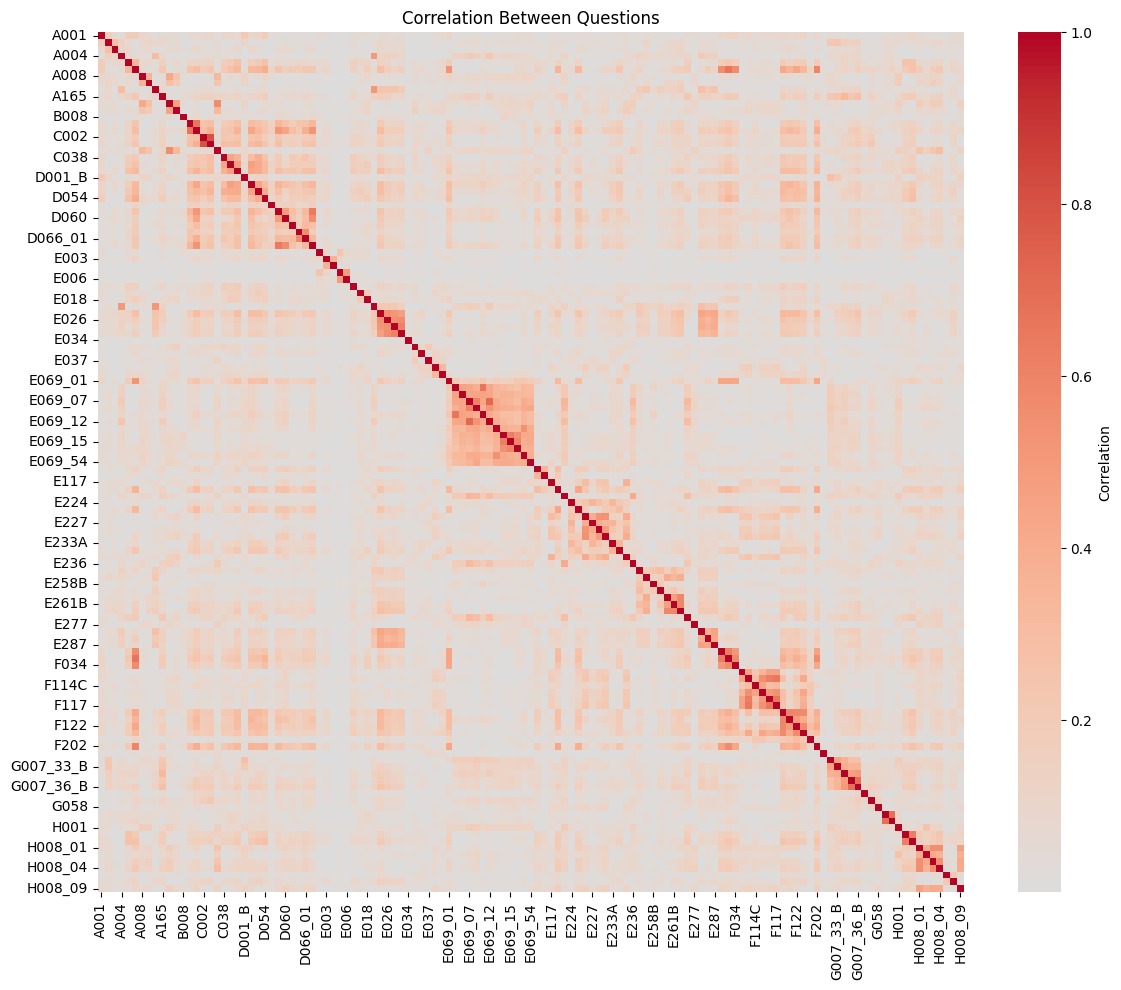

In [103]:
plt.figure(figsize=(12, 10))
sns.heatmap(
    corr.abs(),
    cmap='coolwarm',
    center=0,
    cbar_kws={'label': 'Correlation'}
)
plt.title("Correlation Between Questions")
plt.tight_layout()
plt.show()

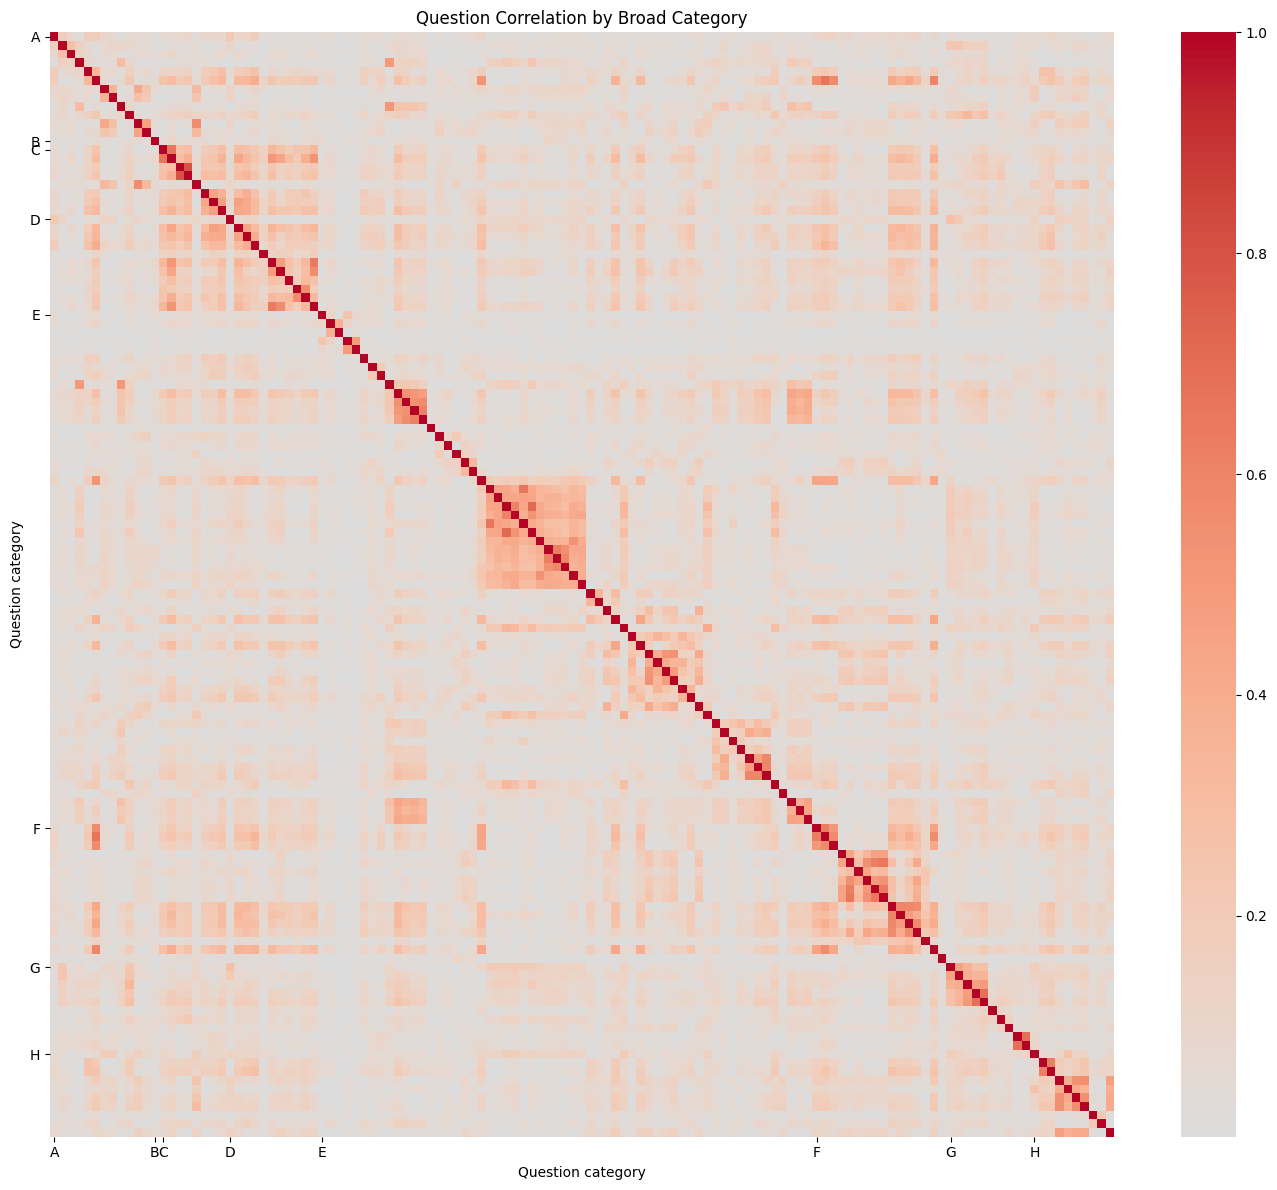

In [102]:
import numpy as np

cats = corr.columns.str[0].values

# find where category changes
tick_pos = []
tick_lab = []

for i in range(len(cats)):
    if i == 0 or cats[i] != cats[i-1]:
        tick_pos.append(i + 0.5)
        tick_lab.append(cats[i])

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr.abs(),
    cmap='coolwarm',
    center=0,
    xticklabels=False,
    yticklabels=False
)

plt.xticks(tick_pos, tick_lab)
plt.yticks(tick_pos, tick_lab)

plt.xlabel("Question category")
plt.ylabel("Question category")
plt.title("Question Correlation by Broad Category")
plt.tight_layout()
plt.show()


In [101]:
corr.describe()

,A001,A002,A003,A004,A005,A006,A008,A009,A062,A165,...,H001,H006_01,H006_02,H008_01,H008_02,H008_03,H008_04,H008_07,H008_08,H008_09
count,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,...,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000,127.000000
mean,0.035898,0.031358,0.013156,0.050139,0.050727,0.079403,0.031583,0.027926,0.032336,0.008307,...,0.032489,0.040837,0.047203,0.032709,0.022132,0.032575,0.035582,0.004963,-0.002964,0.033584
std,0.104785,0.109145,0.105015,0.117056,0.131336,0.201639,0.121176,0.112930,0.129644,0.146882,...,0.120110,0.141108,0.154634,0.151516,0.129099,0.150678,0.154849,0.099147,0.115689,0.133785
min,-0.077425,-0.094792,-0.107791,-0.097147,-0.169344,-0.324422,-0.424308,-0.280759,-0.118555,-0.226012,...,-0.258869,-0.184537,-0.216940,-0.174322,-0.258869,-0.171283,-0.167965,-0.081404,-0.151967,-0.147100
25%,-0.020653,-0.029044,-0.034970,-0.010071,-0.026712,-0.049032,-0.004348,-0.000629,-0.030800,-0.089006,...,-0.034640,-0.043422,-0.048528,-0.051851,-0.039085,-0.052094,-0.054272,-0.030817,-0.063971,-0.029923
50%,0.026808,0.020223,0.000711,0.016727,0.042113,0.050790,0.036027,0.026513,0.000847,-0.003871,...,0.033045,0.014729,0.035632,0.003737,0.012796,-0.003979,-0.005363,-0.011763,-0.021255,0.014728
75%,0.065344,0.061061,0.043157,0.093000,0.096682,0.177450,0.066554,0.049274,0.046162,0.089887,...,0.082915,0.112000,0.126557,0.094515,0.054164,0.095751,0.099873,0.029762,0.039451,0.063980
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [111]:
corr_matrix = corr.abs().copy()

# select upper triangle, remove diagonal
upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))

In [114]:
high_corr = upper.stack().reset_index()
high_corr.columns = ['Question1', 'Question2', 'Correlation']
high_corr = high_corr[high_corr['Correlation'] > 0.6]

# sort descending
high_corr = high_corr.sort_values(by='Correlation', ascending=False)


In [115]:
high_corr

,Question1,Question2,Correlation
1785,C002,C002_01,0.797766
5375,E069_07,E069_12,0.718640
7865,G007_35_B,G007_36_B,0.685810
7935,G062,G063,0.683018
706,A006,F028B,0.664550
1560,C001,C001_01,0.663279
5229,E069_04,E069_10,0.662907
7508,F114B,F117,0.650352
7595,F116,F117,0.648728
2955,D059,D078,0.640488


In [118]:
corr.to_csv("./data/127_items_correlation.csv")

### 🏁

#### 6 Science and Technology Questions

In [ ]:
# df_data = pd.read_csv('./data/WVS_Time_Series_1981-2022_csv_v5_0_original.csv') # took 23 seconds on mine

In [ ]:
# wave_7 = df_data[df_data['S002VS'] == 7]

In [175]:
wave_7 = pd.read_csv('./data/WVS_Wave_7_sci_tech.csv')

In [176]:
codes = {'Q158':'E217',
         'Q159':'E218',
         'Q160':'E220',
         'Q161':'I001',
         'Q162':'I002',
         'Q163':'E234'
}

In [177]:
countries = wave_7['COUNTRY_ALPHA'].unique()

In [178]:
countries

array(['AND', 'ARG', 'ARM', 'AUS', 'BGD', 'BOL', 'BRA', 'CAN', 'CHL',
       'CHN', 'COL', 'CYP', 'CZE', 'DEU', 'ECU', 'EGY', 'ETH', 'GBR',
       'GRC', 'GTM', 'HKG', 'IDN', 'IND', 'IRN', 'IRQ', 'JOR', 'JPN',
       'KAZ', 'KEN', 'KGZ', 'KOR', 'LBN', 'LBY', 'MAC', 'MAR', 'MDV',
       'MEX', 'MMR', 'MNG', 'MYS', 'NGA', 'NIC', 'NIR', 'NLD', 'NZL',
       'PAK', 'PER', 'PHL', 'PRI', 'ROU', 'RUS', 'SGP', 'SRB', 'SVK',
       'THA', 'TJK', 'TUN', 'TUR', 'TWN', 'UKR', 'URY', 'USA', 'UZB',
       'VEN', 'VNM', 'ZWE'], dtype=object)

In [179]:
for item in list(codes.values()):
    for c in countries:
        # Select the country and item
        mask = (wave_7['COUNTRY_ALPHA'] == c)
        
        # Compute mean ignoring negative values
        mean_val = wave_7.loc[mask & (wave_7[item] >= 0), item].mean(skipna=True)
        
        # Replace negative values with the mean
        wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.557768924302789' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '7.291126620139582' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  wave_7.loc[mask & (wave_7[item] < 0), item] = mean_val
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/1176486423.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '6.145145145145145' has dtype incompatible

In [180]:
# Create an empty list to store results
results = []

for item in codes.values():
    for c in countries:
        mask = wave_7['COUNTRY_ALPHA'] == c
        updated_mean = wave_7.loc[mask, item].mean(skipna=True)  # now all values >=0
        results.append({
            'Country': c,
            'Item': item,
            'Updated_Mean': updated_mean
        })

# Convert to a DataFrame
updated_means_df = pd.DataFrame(results)
print(updated_means_df)


    Country  Item  Updated_Mean
0       AND  E217      7.557769
1       ARG  E217      7.522796
2       ARM  E217      8.659802
3       AUS  E217      7.374513
4       BGD  E217      8.714167
..      ...   ...           ...
391     USA  E234      7.561280
392     UZB  E234      8.299096
393     VEN  E234           NaN
394     VNM  E234      8.345000
395     ZWE  E234      7.544398

[396 rows x 3 columns]


In [ ]:
# # List of items to reverse
# items_to_reverse = ['E220', 'I001', 'I002']
# scale_max = 10  # your original 1-10 scale

# # Reverse the values
# mask = updated_means_df['Item'].isin(items_to_reverse)
# updated_means_df.loc[mask, 'Updated_Mean'] = scale_max + 1 - updated_means_df.loc[mask, 'Updated_Mean']

# # Check result
# updated_means_df[updated_means_df['Item'].isin(items_to_reverse)].head()


,Country,Item,Updated_Mean
132,AND,E220,4.854855
133,ARG,E220,4.509336
134,ARM,E220,3.508432
135,AUS,E220,7.078552
136,BGD,E220,4.580000


In [181]:
question_text = {
    'E217': "Science and technology are making our lives healthier, easier, and more comfortable.",
    'E218': "Because of science and technology, there will be more opportunities for the next generation.",
    'E220': "We depend too much on science and not enough on faith.",
    'E234': "All things considered, is the world better or worse off because of science and technology?",
    'I001': "One of the bad effects of science is that it breaks down people’s ideas of right and wrong",
    'I002': "It is not important for me to know about science in my daily life"
    # add other items as needed
}

In [182]:
with open ("./data/gpt5_extra.json", "r") as f:
    llm_dict = json.load(f)

In [183]:
llm_df = pd.DataFrame(llm_dict['country_values'])
llm_df

,Maldives,Nigeria,Andorra,Libya,Ethiopia,Tajikistan,Macao,Turkey,Canada,United Kingdom,...,Greece,Russia,Palestine,Yemen,Vietnam,Belarus,Hong Kong,Peru,Ukraine,model
Q158,8,8,8,8,8,8,9,8,8,8,...,8,9,7,7,9,8,9,8,8,8
Q159,8,8,8,7,8,8,8,8,8,7,...,7,8,6,6,9,8,8,7,8,8
Q160,7,7,4,7,6,6,3,6,3,3,...,6,3,6,7,3,6,3,6,4,4
Q161,6,6,3,6,5,4,2,5,2,3,...,3,3,3,6,2,4,2,5,3,3
Q162,2,3,2,2,3,3,2,3,3,2,...,2,2,2,3,2,3,2,3,2,2
Q163,8,8,8,7,8,8,9,8,8,7,...,8,8,7,7,9,8,8,8,8,8


In [184]:
df_ctry_info = pd.read_csv('./data/WVS_country_info.csv')
wv7_countries = list(df_ctry_info[df_ctry_info['wv_7'] == 1]['country'].values)
abr2ctry = {abr: ctry for abr, ctry in zip(df_ctry_info.abr, df_ctry_info.country)}
continents = ['Oceania','Africa','Asia','Europe','North America','South America']
ctry2continent = {ctry: continent for ctry, continent in zip(df_ctry_info.country, df_ctry_info.continent)}

In [185]:
llm_df = llm_df[[abr2ctry[c] for c in countries]]
llm_df

,Andorra,Argentina,Armenia,Australia,Bangladesh,Bolivia,Brazil,Canada,Chile,China,...,Tunisia,Turkey,Taiwan,Ukraine,Uruguay,United States,Uzbekistan,Venezuela,Vietnam,Zimbabwe
Q158,8,8,8,8,9,8,9,8,8,9,...,8,8,9,8,9,8,8,8,9,8
Q159,8,8,8,8,8,7,8,8,8,9,...,7,8,8,8,9,8,8,7,9,8
Q160,4,4,6,2,6,7,5,3,6,2,...,6,6,3,4,2,5,6,4,3,6
Q161,3,3,5,2,5,6,4,2,3,2,...,4,5,3,3,2,4,4,3,2,4
Q162,2,2,2,2,2,3,3,3,2,2,...,3,3,2,2,2,3,2,2,2,2
Q163,8,8,8,8,8,7,8,8,8,9,...,8,8,9,8,9,8,8,8,9,8


In [186]:
llm_df.index = llm_df.index.map(codes)

In [187]:
llm_df.T

,E217,E218,E220,I001,I002,E234
Andorra,8,8,4,3,2,8
Argentina,8,8,4,3,2,8
Armenia,8,8,6,5,2,8
Australia,8,8,2,2,2,8
Bangladesh,9,8,6,5,2,8
...,...,...,...,...,...,...
United States,8,8,5,4,3,8
Uzbekistan,8,8,6,4,2,8
Venezuela,8,7,4,3,2,8
Vietnam,9,9,3,2,2,9


In [ ]:
# import pandas as pd

# def reverse_code_questions(df, questions_to_reverse, scale_max=10):
#     """
#     Reverse-code specified questions in a DataFrame.

#     Parameters:
#     - df: pd.DataFrame, rows = questions, columns = respondents
#     - questions_to_reverse: list of question IDs/labels to reverse-code
#     - scale_max: maximum value on the scale (default 10)

#     Returns:
#     - df_rev: pd.DataFrame with reverse-coded questions in place
#     """
#     df_rev = df.copy()
#     for q in questions_to_reverse:
#         if q in df_rev.index:
#             df_rev.loc[q] = scale_max + 1 - df_rev.loc[q]  # reverse coding
#         else:
#             print(f"Warning: {q} not found in DataFrame index.")
#     return df_rev


In [ ]:
# llm_rev = reverse_code_questions(llm_df, questions_to_reverse=items_to_reverse)
# print(llm_rev)

      Andorra  Argentina  Armenia  Australia  Bangladesh  Bolivia  Brazil  \
E217        8          8        8          8           9        8       9   
E218        8          8        8          8           8        7       8   
E220        7          7        5          9           5        4       6   
I001        8          8        6          9           6        5       7   
I002        9          9        9          9           9        8       8   
E234        8          8        8          8           8        7       8   

      Canada  Chile  China  ...  Tunisia  Turkey  Taiwan  Ukraine  Uruguay  \
E217       8      8      9  ...        8       8       9        8        9   
E218       8      8      9  ...        7       8       8        8        9   
E220       8      5      9  ...        5       5       8        7        9   
I001       9      8      9  ...        7       6       8        8        9   
I002       8      9      9  ...        8       8       9        9     

In [188]:
# Drop any NaNs to avoid issues in KDE
df_plot = updated_means_df.dropna(subset=['Updated_Mean'])

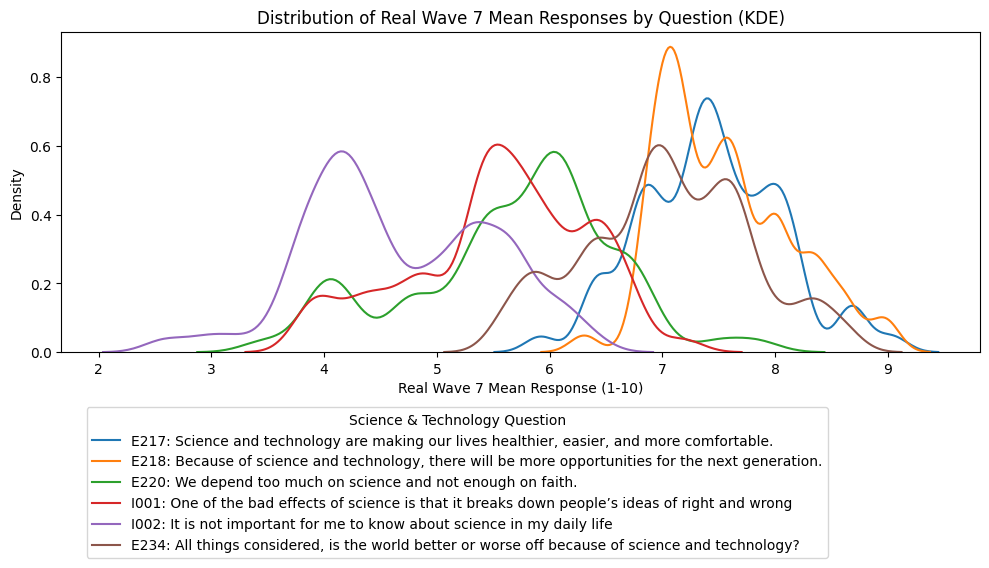

In [189]:
import seaborn as sns
import matplotlib.pyplot as plt
plt.style.use('default')


# Plot KDE for each question/item
plt.figure(figsize=(10,6))
for item in df_plot['Item'].unique():
    sns.kdeplot(
        data=df_plot[df_plot['Item'] == item],
        x='Updated_Mean',
        label=f'{codes.get(item, item)}: {question_text.get(item, item)}',  # default to code if statement not found
        bw_adjust=0.5
    )

plt.title("Distribution of Real Wave 7 Mean Responses by Question (KDE)")
plt.xlabel("Real Wave 7 Mean Response (1-10)")
plt.ylabel("Density")
plt.legend(title="Science & Technology Question", bbox_to_anchor=(0.02, -0.15), loc='upper left')  # outside legend
plt.tight_layout()
plt.savefig('./gpt5_science_tech_attitude_real_data.png', dpi=300)
plt.show()

##### Raw Distribution

In [190]:
codes = {v: k for k, v in codes.items()}

In [191]:
codes

{'E217': 'Q158',
 'E218': 'Q159',
 'E220': 'Q160',
 'I001': 'Q161',
 'I002': 'Q162',
 'E234': 'Q163'}

In [192]:
question_text

{'E217': 'Science and technology are making our lives healthier, easier, and more comfortable.',
 'E218': 'Because of science and technology, there will be more opportunities for the next generation.',
 'E220': 'We depend too much on science and not enough on faith.',
 'E234': 'All things considered, is the world better or worse off because of science and technology?',
 'I001': 'One of the bad effects of science is that it breaks down people’s ideas of right and wrong',
 'I002': 'It is not important for me to know about science in my daily life'}

In [193]:
# Auto wrap function (wrap at ~50 chars)
import textwrap

def wrap_text(s, width=50):
    return "\n".join(textwrap.wrap(s, width))

long_df['wrapped_label'] = long_df['item'].map(
    lambda x: wrap_text(codes.get(x, x) + ": " + question_text.get(x, x), width=50)
)

g = sns.displot(
    data=long_df,
    x='response',
    col='wrapped_label',
    col_wrap=3,
    bins=10,
    binrange=(1,10),
    stat='frequency',
    element='step',
    fill=False,
    height=3.2,
    aspect=1.1
)

g.set(xlim=(1, 10))
g.set_axis_labels("Response (1–10)", "Density")

# Adjust title font/spacing
g.set_titles("{col_name}", size=9, pad=8)
g.fig.subplots_adjust(top=0.88, hspace=0.35, wspace=0.25)

g.savefig(
    "./science_tech_attitude_real_data_hist_faceted_fixedx.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()


NameError: name 'long_df' is not defined

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


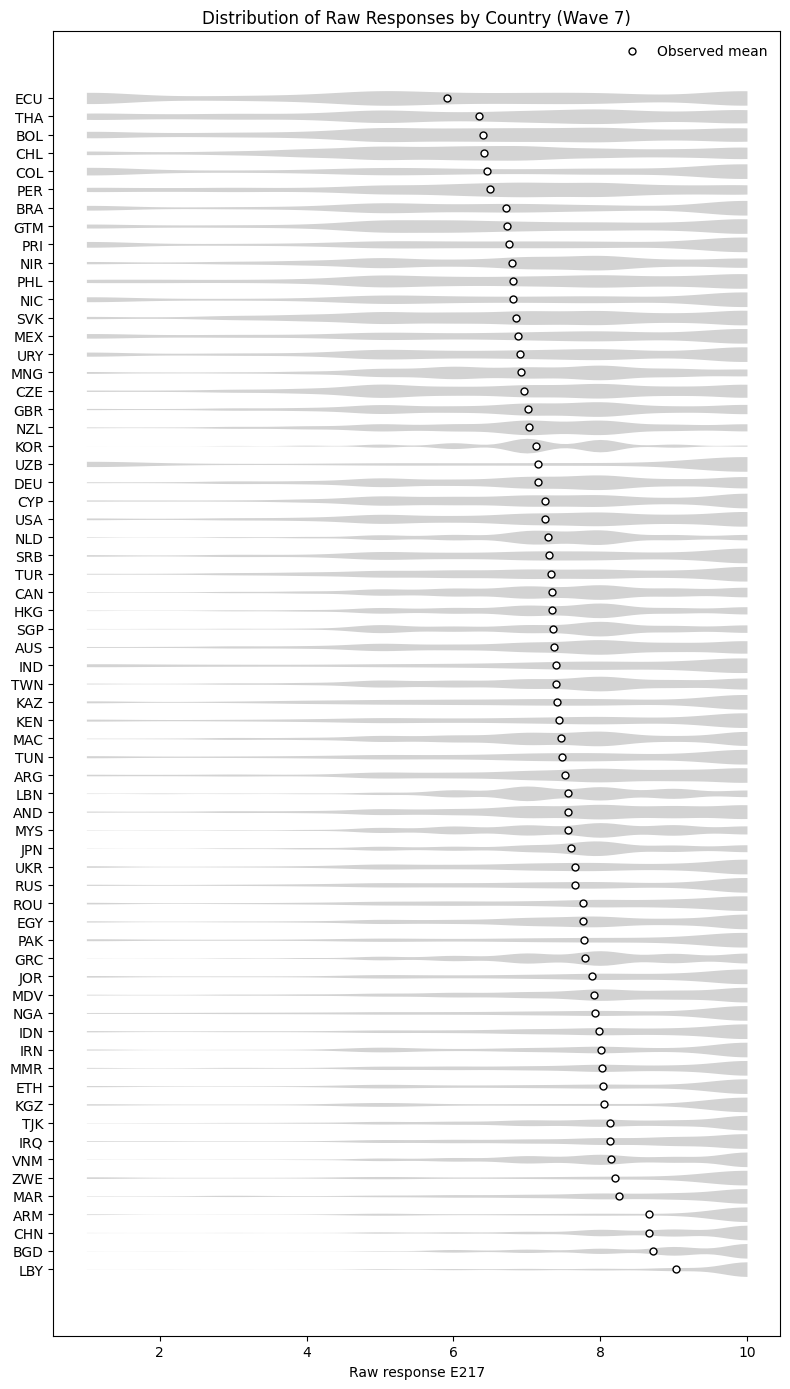

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


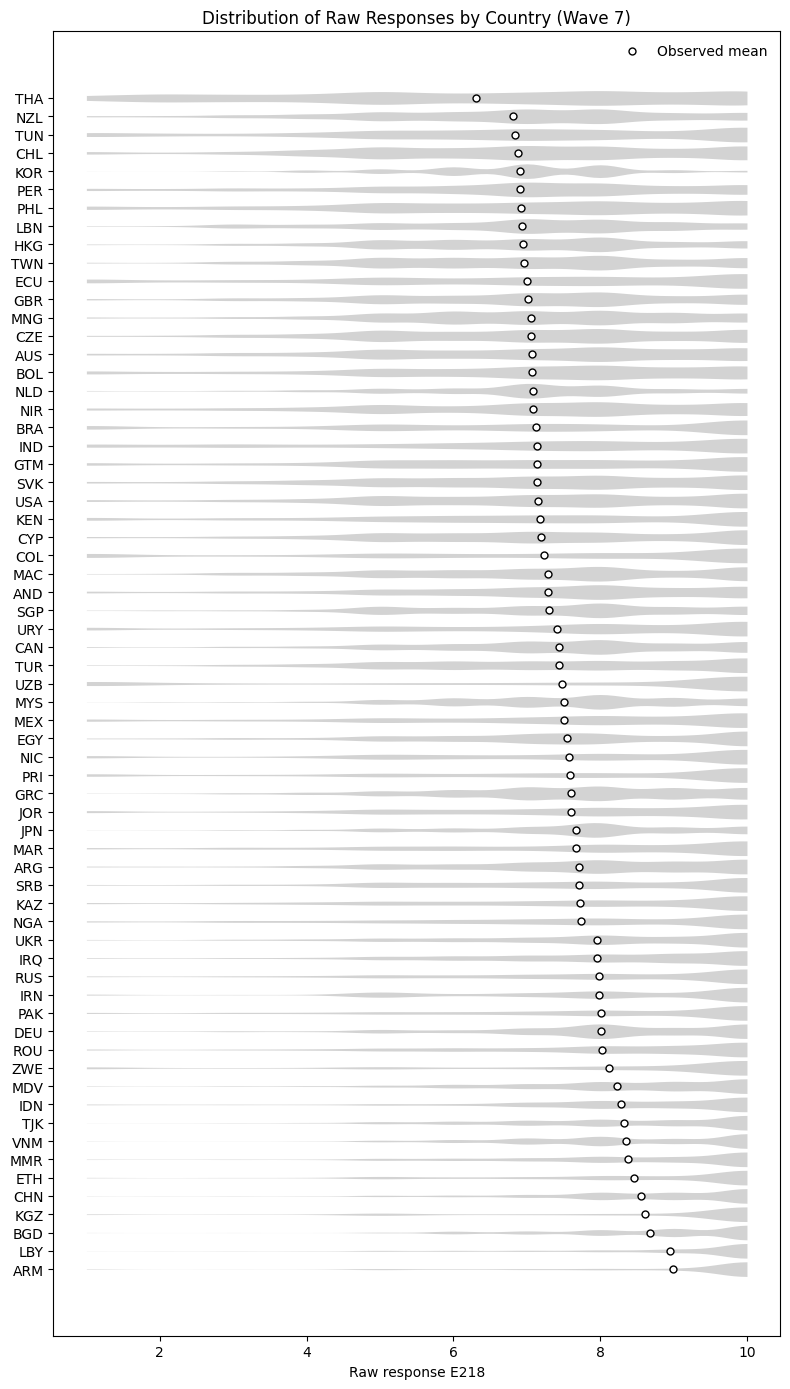

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


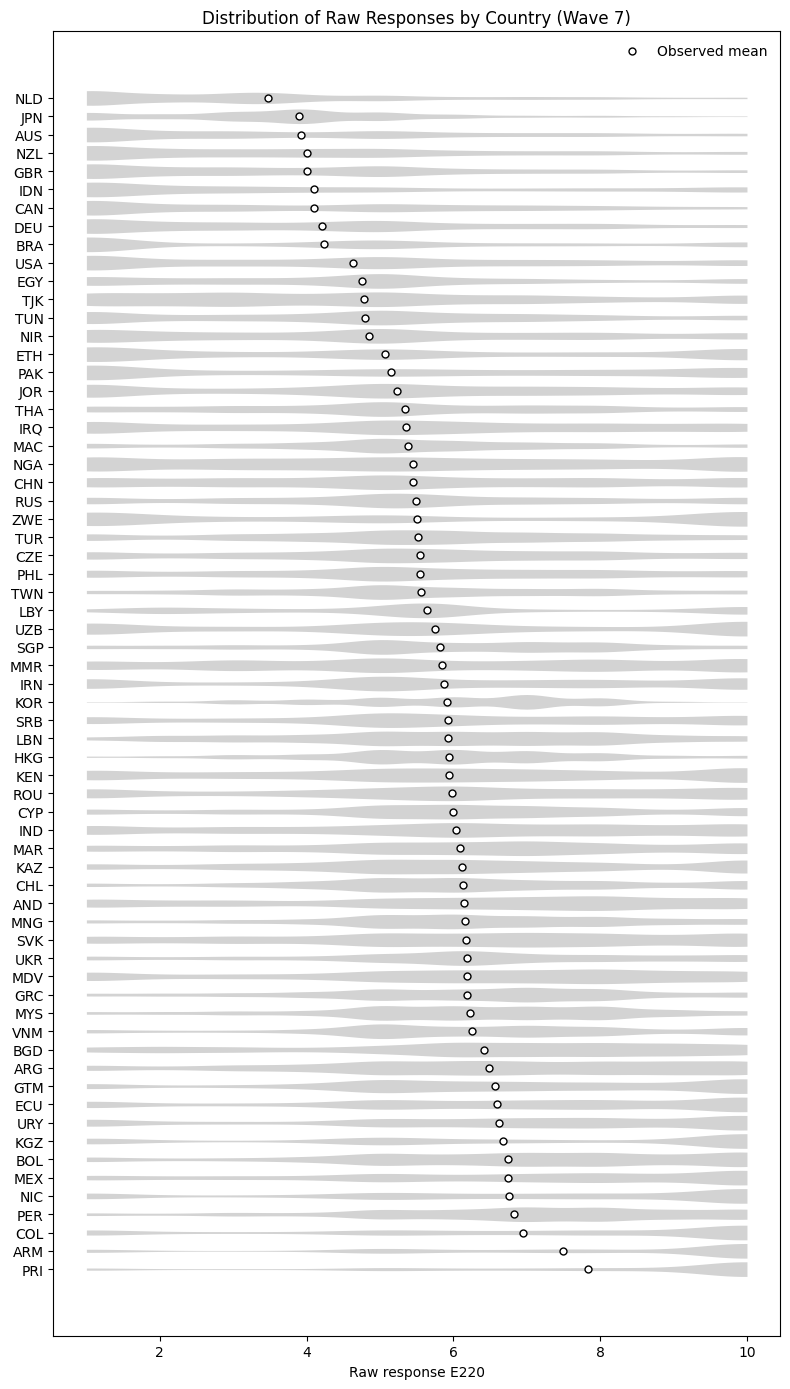

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


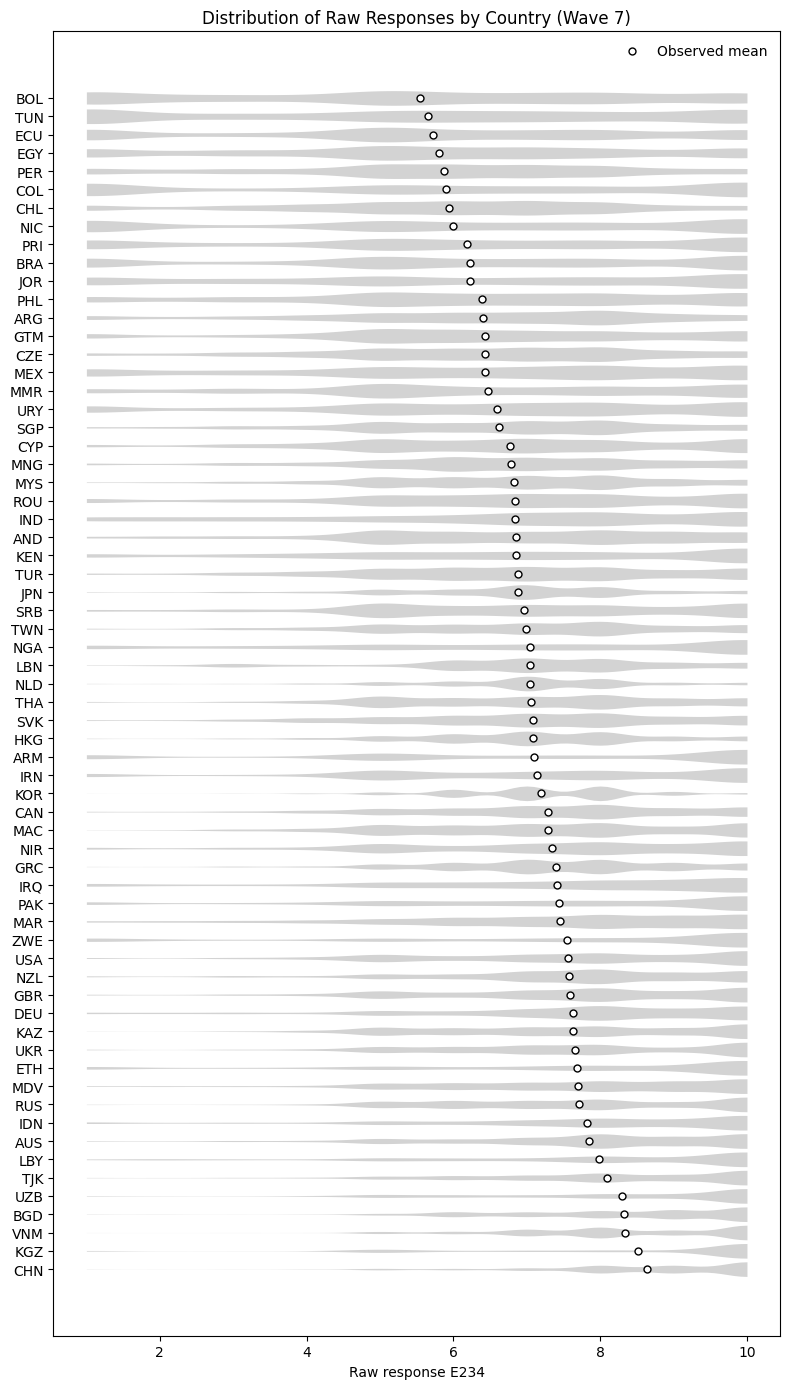

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


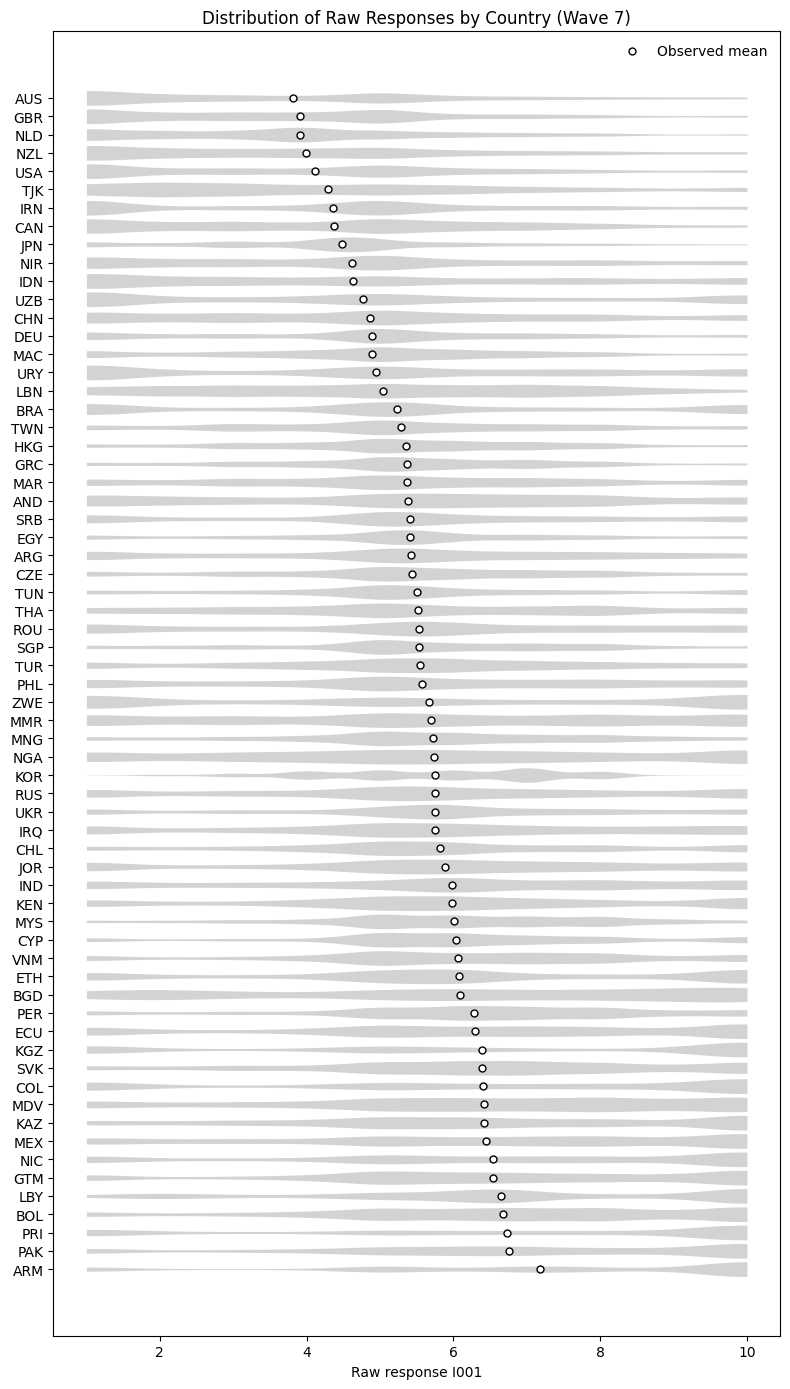

/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `scale` parameter has been renamed and will be removed in v0.15.0. Pass `density_norm='width'` for the same effect.
  sns.violinplot(
/var/folders/6d/fyqclspj02dcr6qdd_tdzjf80000gn/T/ipykernel_1361/3365735816.py:16: FutureWarning: 

The `bw` parameter is deprecated in favor of `bw_method`/`bw_adjust`.
Setting `bw_method=0.2`, but please see docs for the new parameters
and update your code. This will become an error in seaborn v0.15.0.

  sns.violinplot(


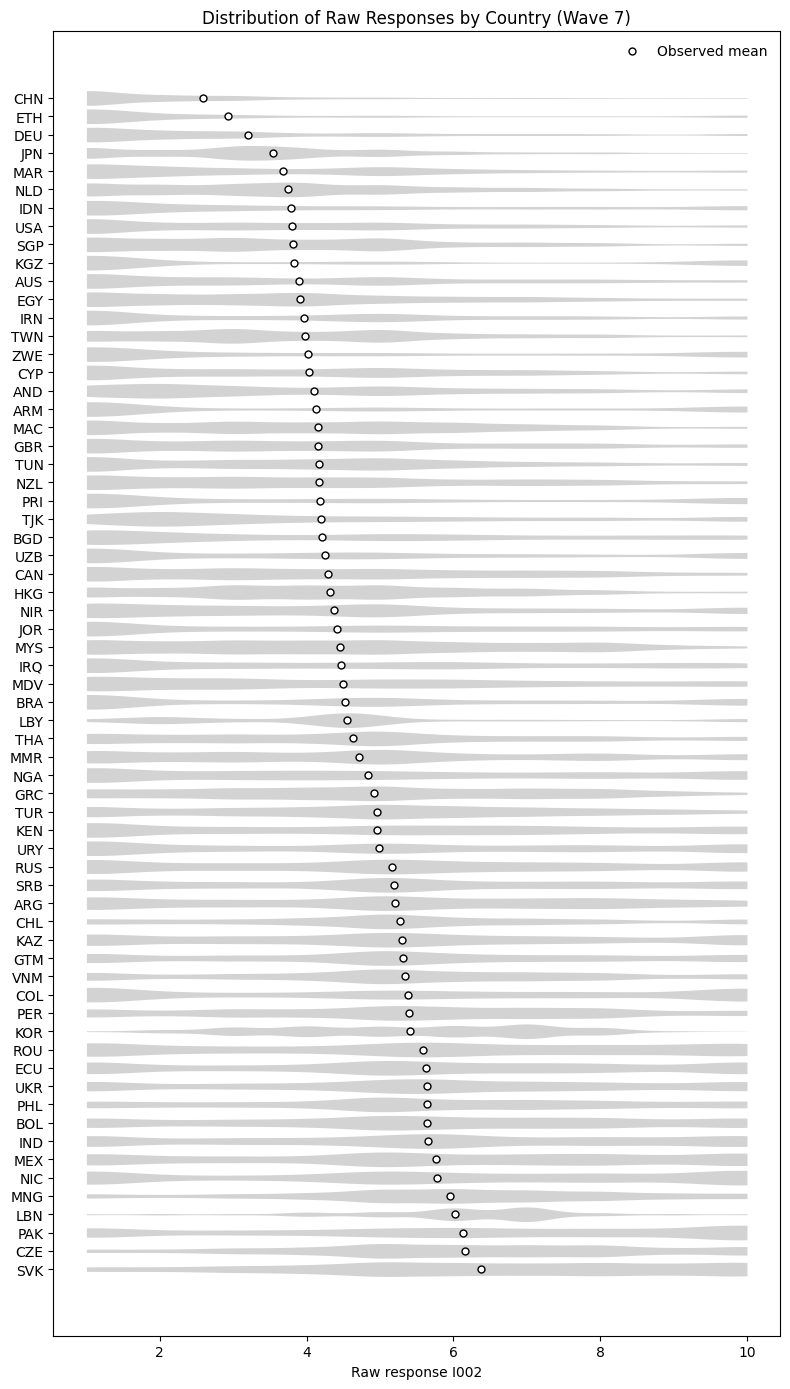

In [194]:
for i in question_text.keys():# Drop missing
    df = wave_7[['COUNTRY_ALPHA', i]].dropna()

    # Country means
    country_means = (
        df.groupby('COUNTRY_ALPHA')[i]
        .mean()
        .sort_values()
    )

    # Use this order everywhere (Panel A + B)
    country_order = country_means.index.tolist()

    plt.figure(figsize=(8, 14))

    sns.violinplot(
        data=df,
        y='COUNTRY_ALPHA',
        x=i,
        order=country_order,
        orient='h',
        cut=0,
        scale='width',
        inner=None,
        linewidth=0,
        color='lightgray',
        bw = 0.2
    )

    # Overlay observed mean
    plt.scatter(
        country_means.values,
        range(len(country_means)),
        color='white',
        edgecolor='black',
        s=25,
        zorder=3,
        label='Observed mean'
    )

    plt.xlabel(f'Raw response {i}')
    plt.ylabel('')
    plt.title('Distribution of Raw Responses by Country (Wave 7)')
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.show()


##### Country

In [195]:
llm_df.head()

,Andorra,Argentina,Armenia,Australia,Bangladesh,Bolivia,Brazil,Canada,Chile,China,...,Tunisia,Turkey,Taiwan,Ukraine,Uruguay,United States,Uzbekistan,Venezuela,Vietnam,Zimbabwe
E217,8,8,8,8,9,8,9,8,8,9,...,8,8,9,8,9,8,8,8,9,8
E218,8,8,8,8,8,7,8,8,8,9,...,7,8,8,8,9,8,8,7,9,8
E220,4,4,6,2,6,7,5,3,6,2,...,6,6,3,4,2,5,6,4,3,6
I001,3,3,5,2,5,6,4,2,3,2,...,4,5,3,3,2,4,4,3,2,4
I002,2,2,2,2,2,3,3,3,2,2,...,3,3,2,2,2,3,2,2,2,2


In [196]:
df_plot

,Country,Item,Updated_Mean
0,AND,E217,7.557769
1,ARG,E217,7.522796
2,ARM,E217,8.659802
3,AUS,E217,7.374513
4,BGD,E217,8.714167
...,...,...,...
390,URY,E234,6.596741
391,USA,E234,7.561280
392,UZB,E234,8.299096
394,VNM,E234,8.345000


In [197]:
# Extract LLM predictions for one item
predicted = (
    llm_df
    .loc['E217']
    .rename('predicted')
    .reset_index()
    .rename(columns={'index': 'Country'})
)


In [198]:
observed = (
    df_plot
    .query("Item == 'E217'")
    [['Country', 'Updated_Mean']]
    .rename(columns={'Updated_Mean': 'observed'})
)


In [199]:
observed['Country'] = observed['Country'].map(abr2ctry)


In [200]:
observed

,Country,observed
0,Andorra,7.557769
1,Argentina,7.522796
2,Armenia,8.659802
3,Australia,7.374513
4,Bangladesh,8.714167
...,...,...
60,Uruguay,6.907895
61,United States,7.251362
62,Uzbekistan,7.146916
64,Vietnam,8.151667


In [201]:
df_country = observed.merge(
    predicted[['Country', 'predicted']],
    on='Country',
    how='inner'
)
df_country

,Country,observed,predicted
0,Andorra,7.557769,8
1,Argentina,7.522796,8
2,Armenia,8.659802,8
3,Australia,7.374513,8
4,Bangladesh,8.714167,9
...,...,...,...
60,Uruguay,6.907895,9
61,United States,7.251362,8
62,Uzbekistan,7.146916,8
63,Vietnam,8.151667,9


In [202]:
SCALE_MIN = 1
SCALE_MAX = 10

scale_label_default = "1 = Completely disagree · 10 = Completely agree"
scale_label_q163 = "1 = A lot worse off · 10 = A lot better off"


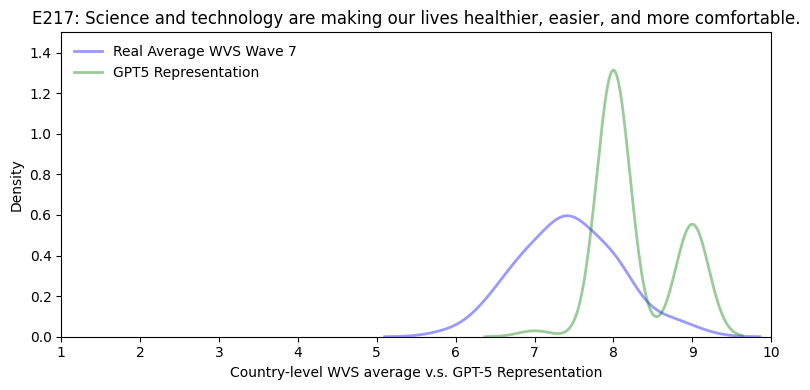

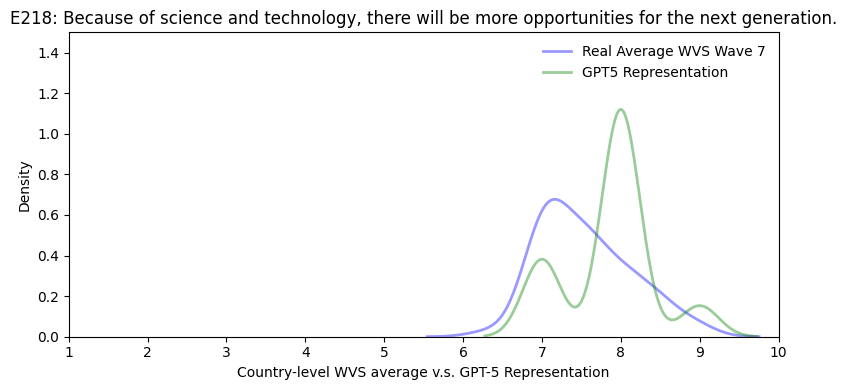

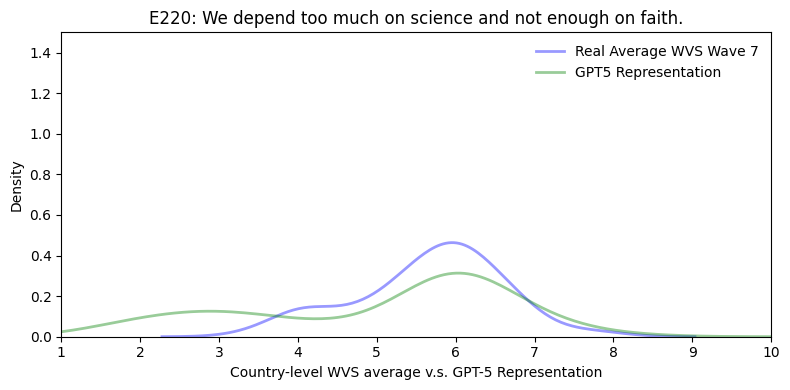

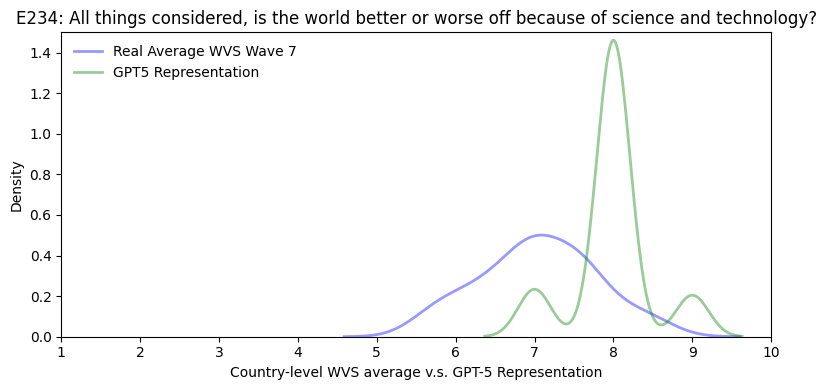

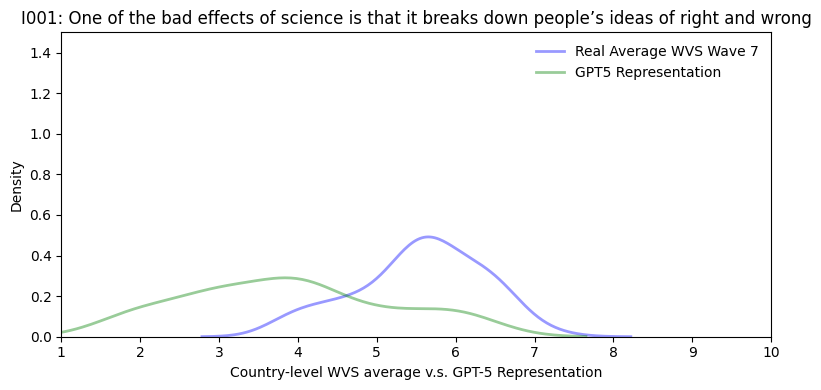

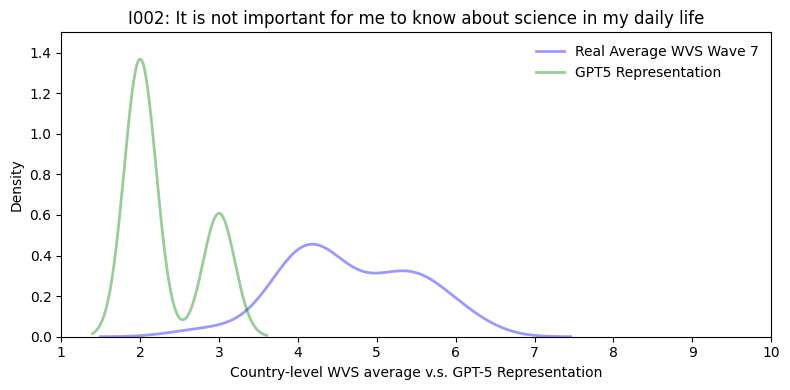

In [203]:
for q in question_text.keys():

    # Extract LLM predictions for one item
    predicted = (
        llm_df
        .loc[q]
        .rename('predicted')
        .reset_index()
        .rename(columns={'index': 'Country'})
    )

    observed = (
        df_plot
        .query(f"Item == '{q}'")
        [['Country', 'Updated_Mean']]
        .rename(columns={'Updated_Mean': 'observed'})
    )

    observed['Country'] = observed['Country'].map(abr2ctry)

    df_country = observed.merge(
        predicted[['Country', 'predicted']],
        on='Country',
        how='inner'
    )

    plt.figure(figsize=(8, 4))
    plt.xlim(1, 10)
    plt.ylim(0, 1.5)

    sns.kdeplot(
        df_country['observed'],
        fill=False,
        alpha=0.4,
        linewidth=2,
        label='Real Average WVS Wave 7',
        color = 'Blue'
    )

    sns.kdeplot(
        df_country['predicted'],
        fill=False,
        alpha=0.4,
        linewidth=2,
        label='GPT5 Representation',
        color = 'Green'
    )

    plt.xlabel('Country-level WVS average v.s. GPT-5 Representation')
    plt.ylabel('Density')
    plt.title(f'{q}: {question_text[q]}')
    plt.legend(frameon=False)

    plt.tight_layout()
    plt.savefig(f'./images/{q}_{question_text[q]}.png', dpi = 300)
    plt.show()


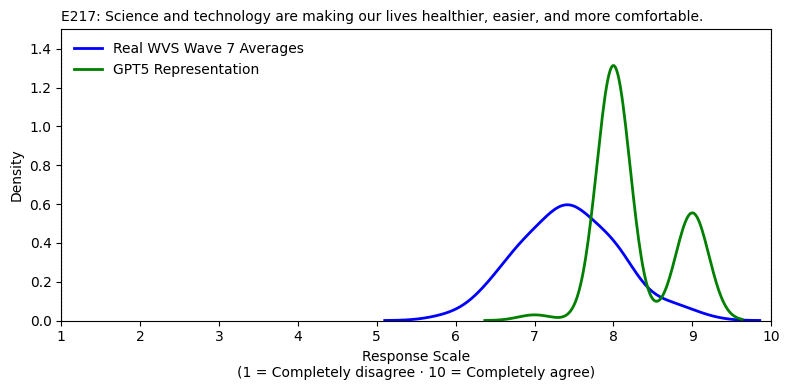

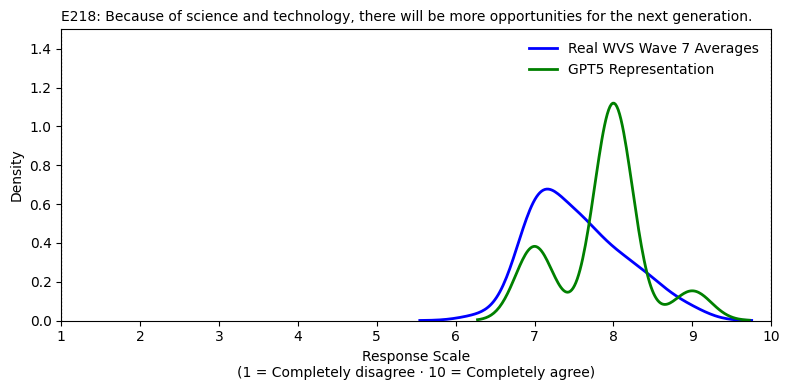

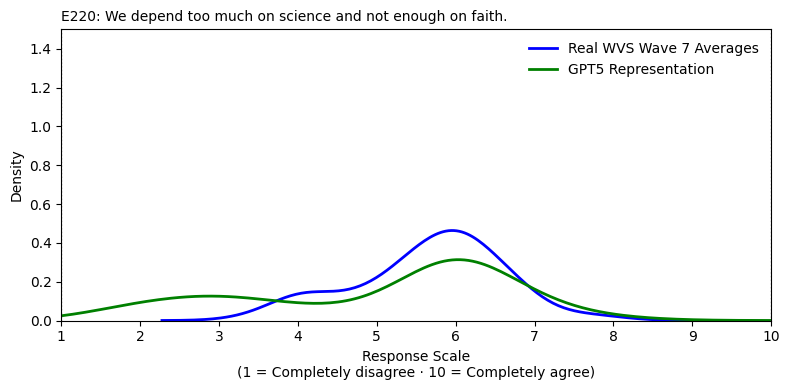

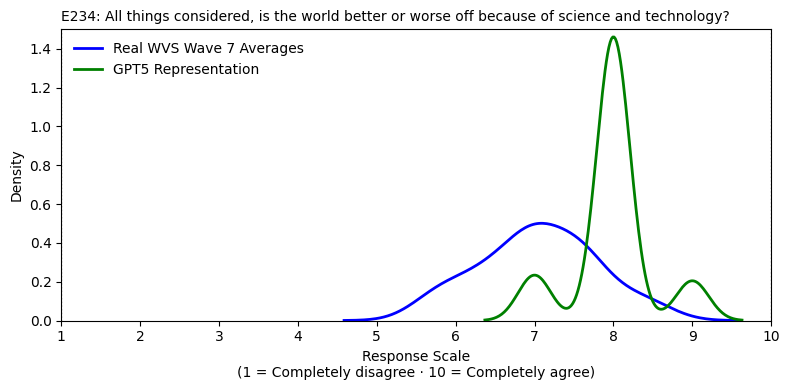

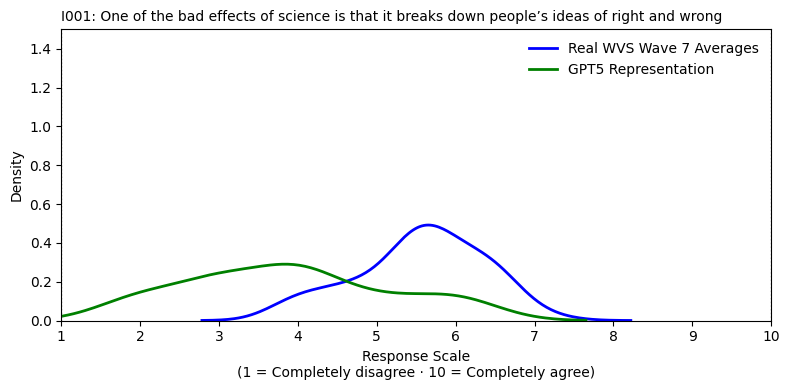

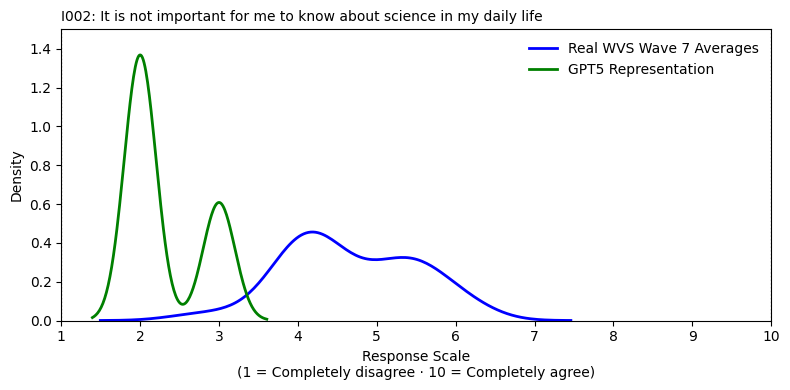

In [204]:
for q in question_text.keys():

    # Extract LLM predictions
    predicted = (
        llm_df
        .loc[q]
        .rename('predicted')
        .reset_index()
        .rename(columns={'index': 'Country'})
    )

    # Observed country means
    observed = (
        df_plot
        .query(f"Item == '{q}'")
        [['Country', 'Updated_Mean']]
        .rename(columns={'Updated_Mean': 'observed'})
    )

    observed['Country'] = observed['Country'].map(abr2ctry)

    df_country = observed.merge(
        predicted[['Country', 'predicted']],
        on='Country',
        how='inner'
    )

    # Choose correct scale description
    scale_text = scale_label_q163 if q == "Q163" else scale_label_default

    plt.figure(figsize=(8, 4))
    plt.xlim(SCALE_MIN, SCALE_MAX)
    plt.ylim(0, 1.5)

    sns.kdeplot(
        df_country['observed'],
        fill=False,
        linewidth=2,
        label='Real WVS Wave 7 Averages',
        color='blue'
    )

    sns.kdeplot(
        df_country['predicted'],
        fill=False,
        linewidth=2,
        label='GPT5 Representation',
        color='green'
    )

    # Optional but recommended: reference lines at scale endpoints
    plt.axvline(SCALE_MIN, linestyle=':', linewidth=1, color='gray')
    plt.axvline(SCALE_MAX, linestyle=':', linewidth=1, color='gray')

    plt.xlabel(
        f'Response Scale\n({scale_text})'
    )
    plt.ylabel('Density')

    plt.title(
        f'{q}: {question_text[q]}',
        loc='left',
        fontsize=10
    )

    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(f'./images/{q}_{question_text[q]}_distribution.png', dpi=300)
    plt.show()


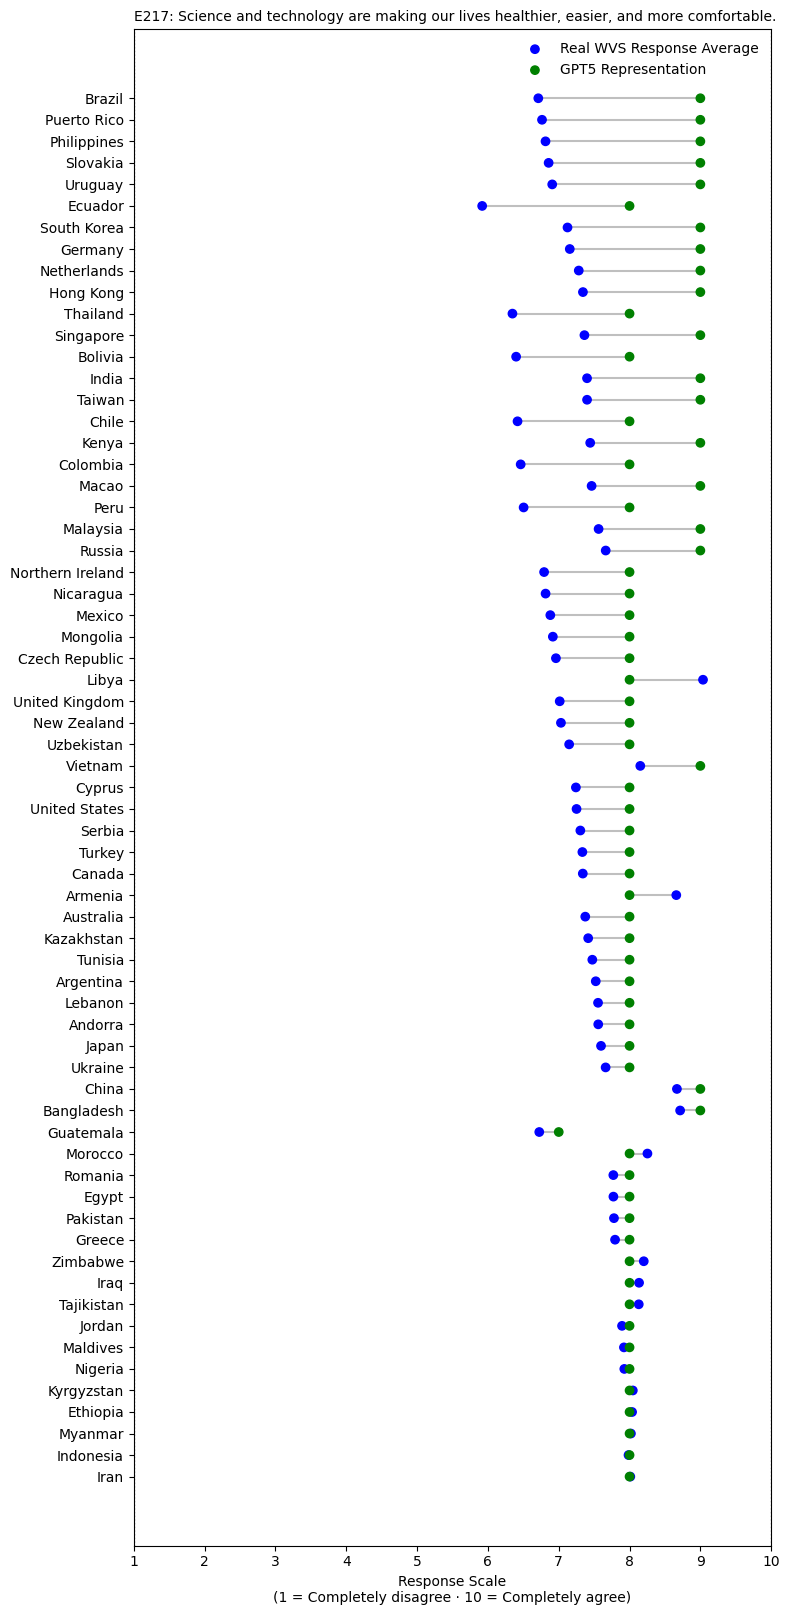

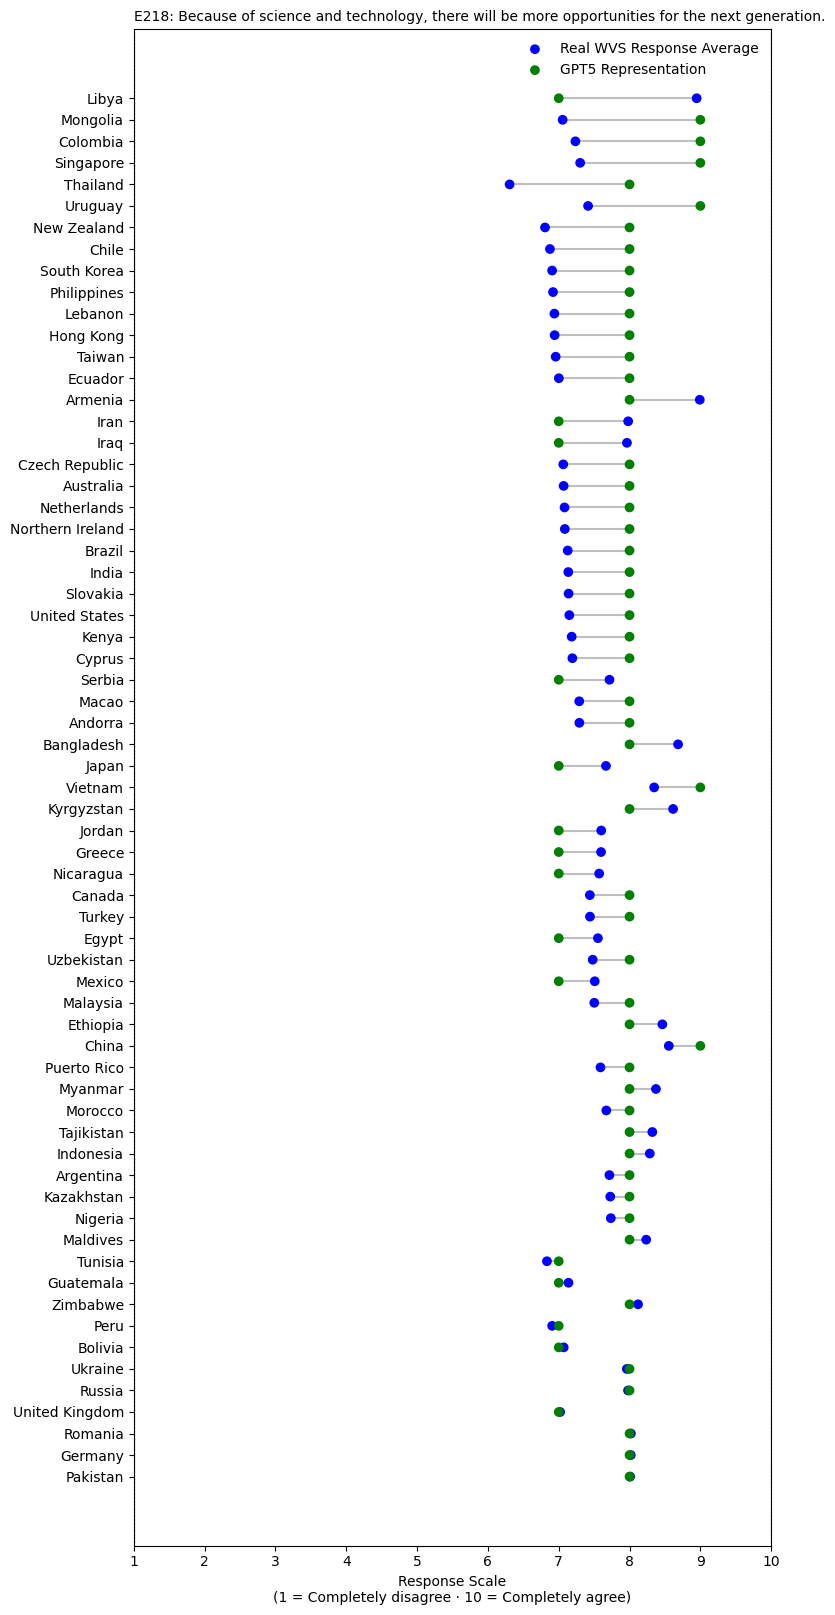

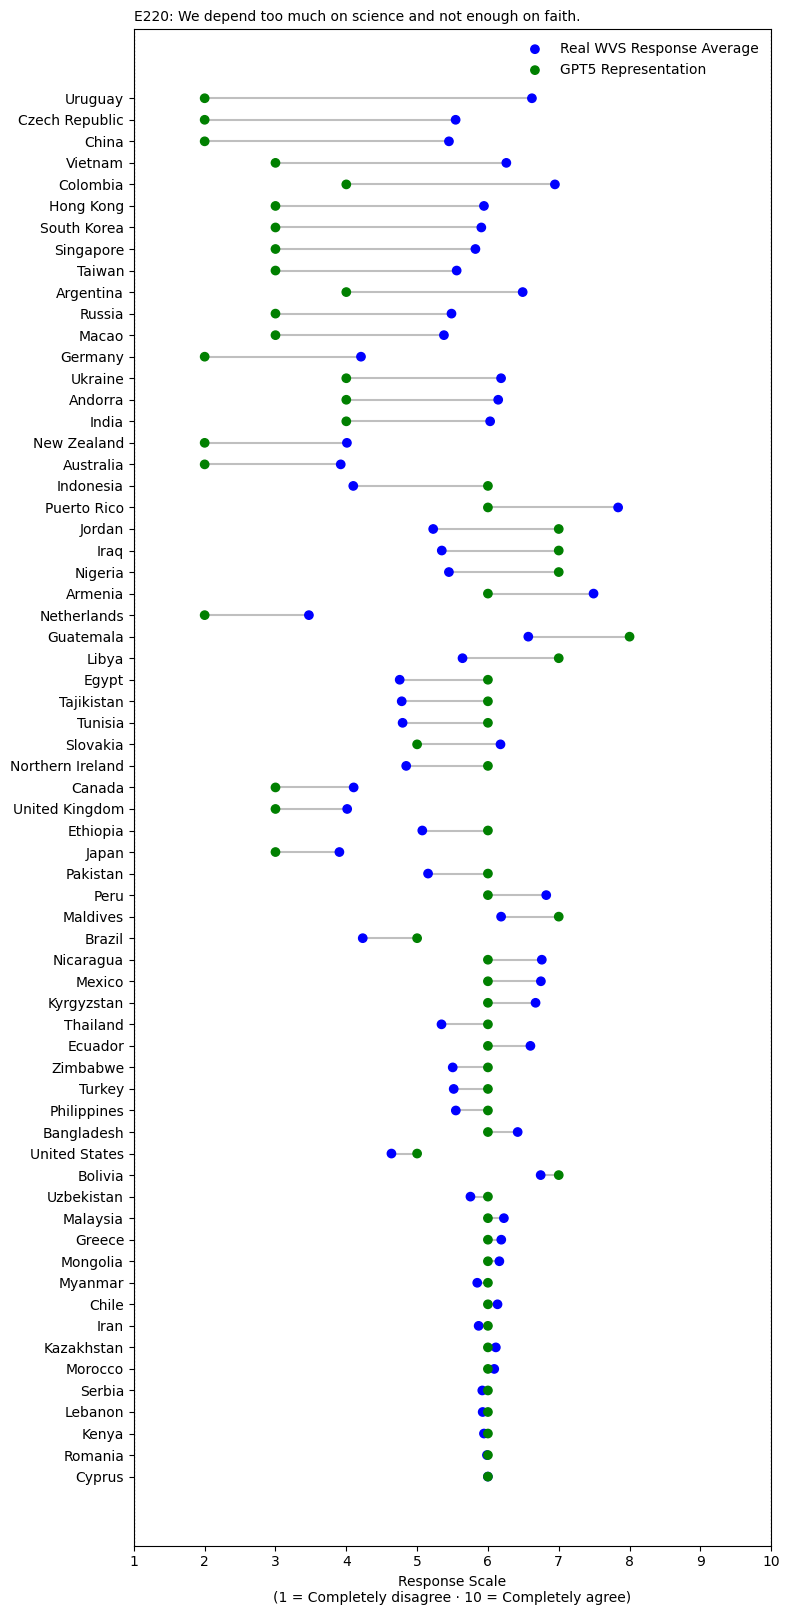

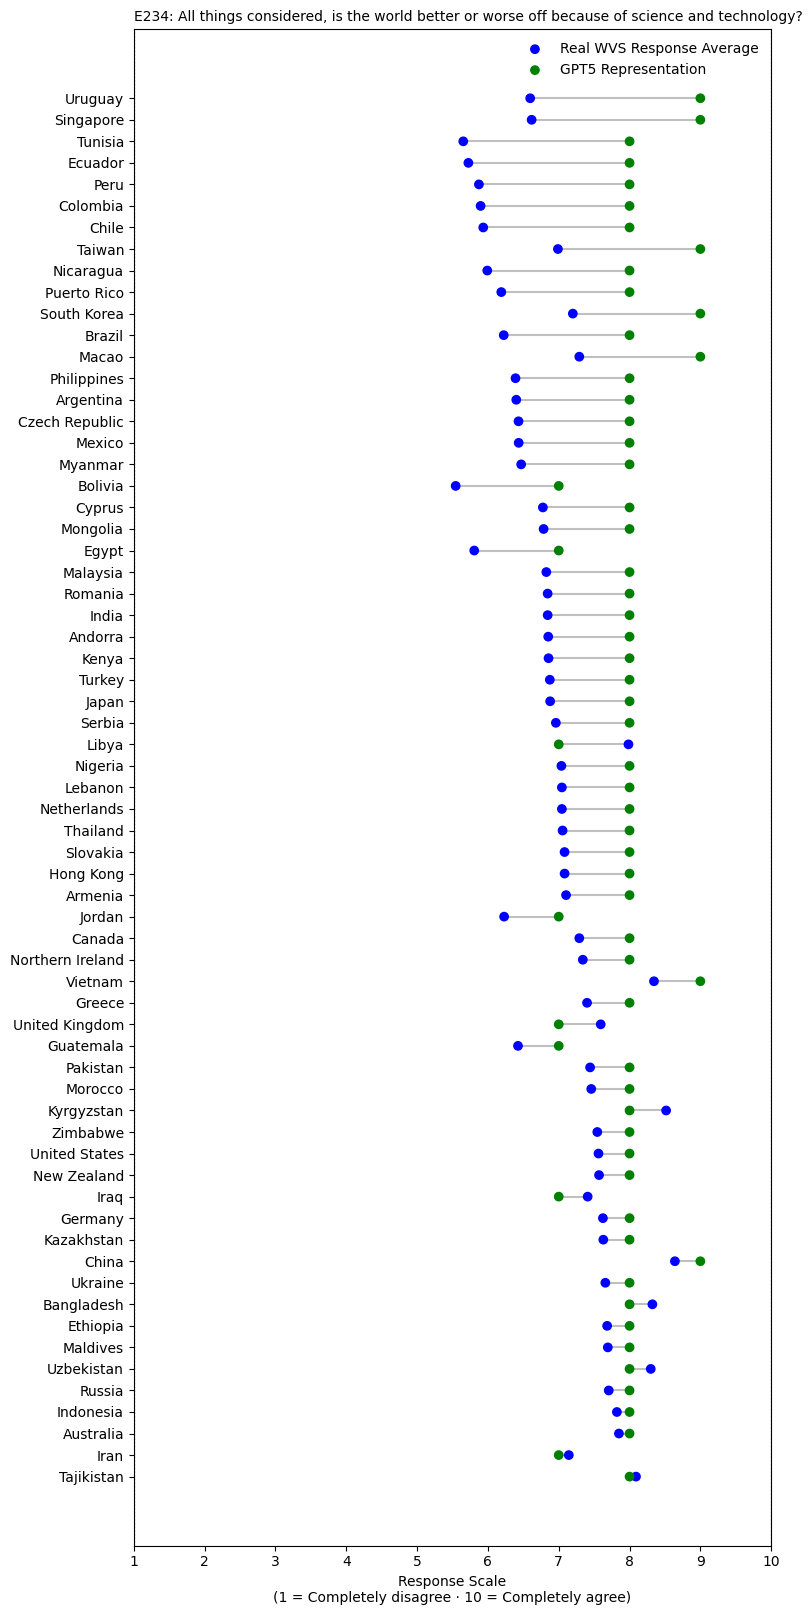

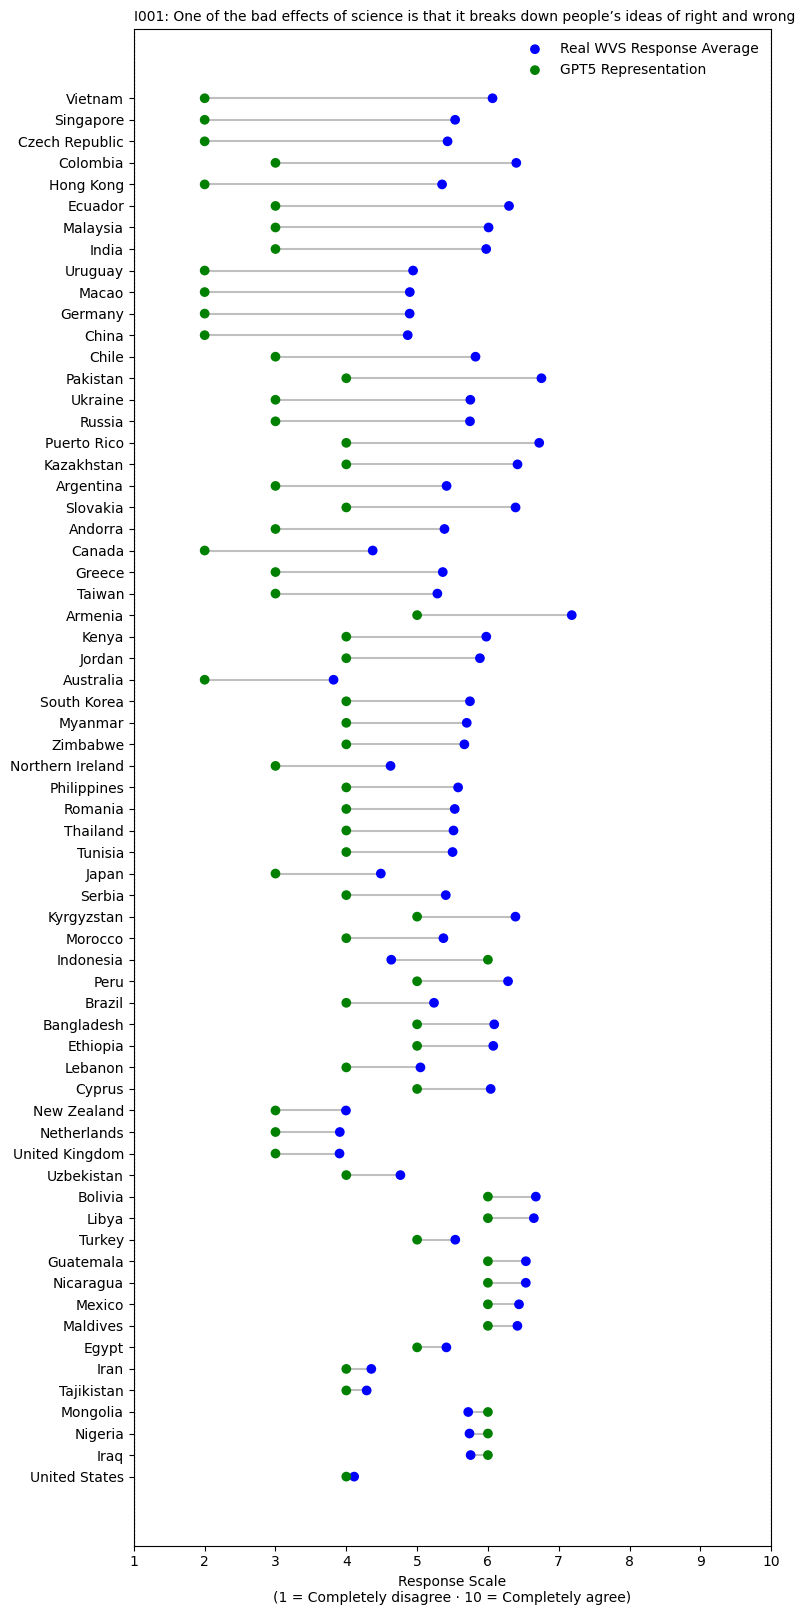

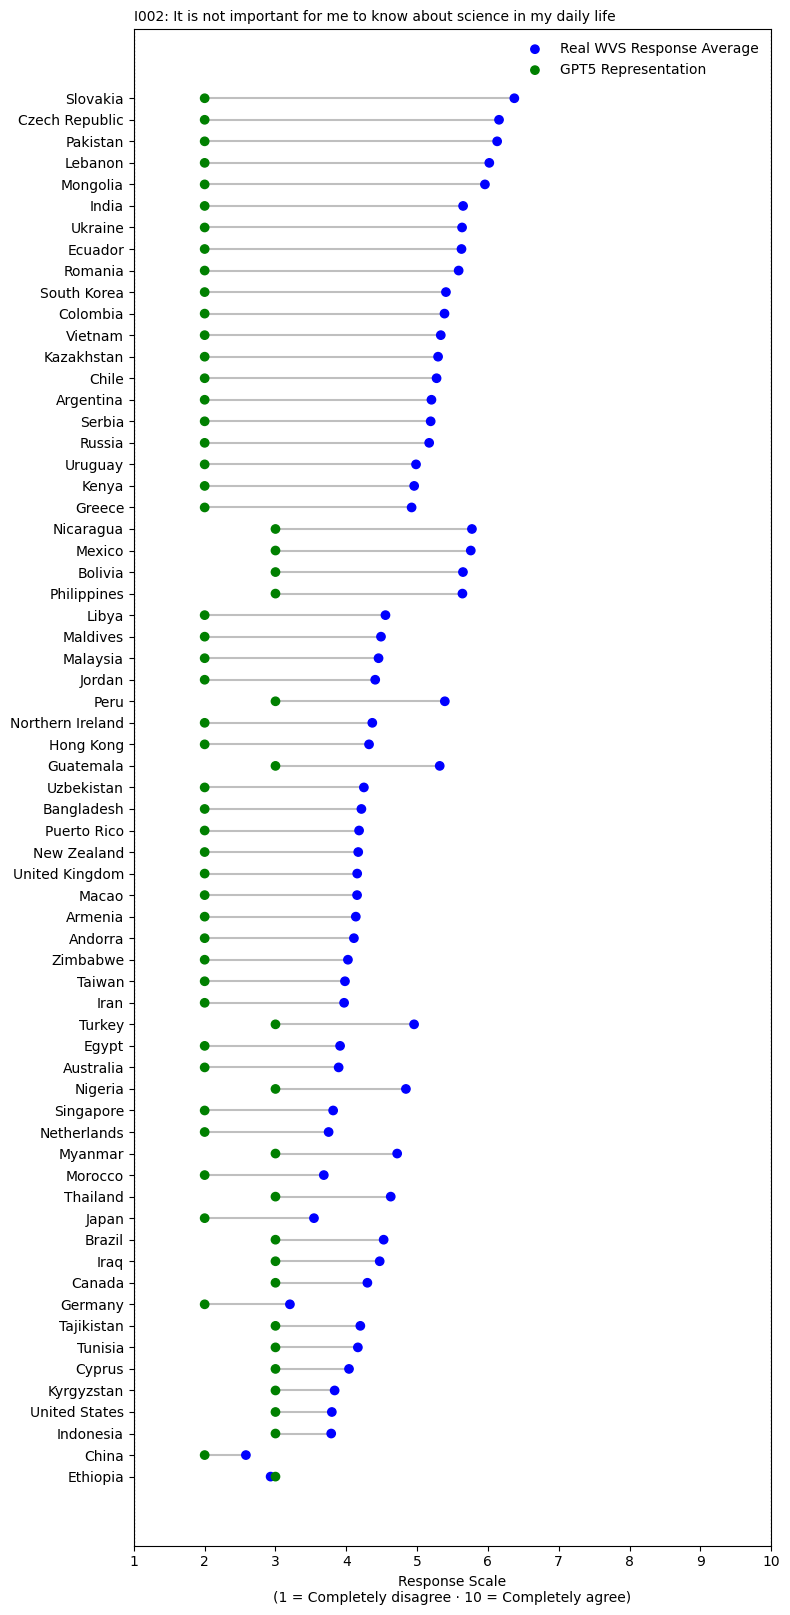

In [205]:
import matplotlib.pyplot as plt
import numpy as np

for q in question_text.keys():

    # --- Extract LLM predictions ---
    predicted = (
        llm_df
        .loc[q]
        .rename('predicted')
        .reset_index()
        .rename(columns={'index': 'Country'})
    )

    # --- Observed country means ---
    observed = (
        df_plot
        .query(f"Item == '{q}'")
        [['Country', 'Updated_Mean']]
        .rename(columns={'Updated_Mean': 'observed'})
    )

    observed['Country'] = observed['Country'].map(abr2ctry)

    # --- Merge ---
    df_country = observed.merge(
        predicted[['Country', 'predicted']],
        on='Country',
        how='inner'
    )

    df_country['abs_diff'] = (
        df_country['observed'] - df_country['predicted']
    ).abs()

    # Sort countries for readability (optional but recommended)
    df_country = df_country.sort_values('abs_diff')

    countries = df_country['Country']
    y_pos = np.arange(len(df_country))

    # --- Plot ---
    plt.figure(figsize=(8, max(4, len(df_country) * 0.25)))

    # Draw dumbbell lines
    for i, row in df_country.iterrows():
        plt.plot(
            [row['observed'], row['predicted']],
            [y_pos[df_country.index.get_loc(i)]] * 2,
            color='gray',
            alpha=0.5,
            zorder=1
        )

    # Conditional coloring: agreement → gray
    agree = df_country['observed'] == df_country['predicted']

    obs_colors = np.where(agree, 'gray', 'blue')
    pred_colors = np.where(agree, 'gray', 'green')

    # Plot dots
    plt.scatter(
        df_country['observed'],
        y_pos,
        color=obs_colors,
        label='Real WVS Response Average',
        zorder=3
    )

    plt.scatter(
        df_country['predicted'],
        y_pos,
        color=pred_colors,
        label='GPT5 Representation',
        zorder=3
    )

    # --- Axes & labels ---
    scale_text = scale_label_q163 if q == "Q163" else scale_label_default

    plt.xlim(SCALE_MIN, SCALE_MAX)
    plt.yticks(y_pos, countries)
    plt.xlabel(f'Response Scale\n({scale_text})')

    # Reference lines
    plt.axvline(SCALE_MIN, linestyle=':', linewidth=1, color='gray')
    plt.axvline(SCALE_MAX, linestyle=':', linewidth=1, color='gray')

    plt.title(
        f'{q}: {question_text[q]}',
        loc='left',
        fontsize=10
    )

    plt.legend(frameon=False)
    plt.tight_layout()

    plt.savefig(f'./images/{q}_{question_text[q]}_dumbbell.png', dpi=300)
    plt.show()
